## Coverage calculations

All files on farm in `/home/ctbrown/scratch3/2025-workflow-core99/`

In [1]:
# base checkout of workflow directory is here:
BASE='/home/ctbrown/scratch3/2025-workflow-core99/'

# outputs from running `do_mapping`:
BASE_OUTPUTS=BASE+'/outputs.mapping/bams.cds.rand'

# where to place figures
FIG_OUT=BASE+'/outputs.figures/'

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import scipy
import math

import seaborn as sns
from matplotlib.legend_handler import HandlerTuple

In [3]:
NAMES = [ x.strip() for x in open(BASE+'/inputs.mapping/names-plus.list') ]
print(f'loaded {len(NAMES)} species names')

SPECIAL = [ x.strip() for x in open(BASE+'/inputs.mapping/names.list') ]
print(f'loaded {len(NAMES)} special species names')

NAMES.sort()
NAMES

loaded 26 species names
loaded 26 special species names


['s__Bariatricus sp004560705',
 's__Bifidobacterium thermacidophilum',
 's__Blautia_A sp945872375',
 's__CAG-269 sp014846485',
 's__CAG-465 sp000433755',
 's__CAG-873 sp016302215',
 's__Cryptobacteroides sp900546925',
 's__Fimisoma sp002320005',
 's__Gemmiger qucibialis',
 's__Holdemanella porci',
 's__JAFBIX01 sp021531895',
 's__JALFVM01 sp022787145',
 's__Lactobacillus amylovorus',
 's__Mogibacterium_A kristiansenii',
 's__Phascolarctobacterium_A succinatutens',
 's__Phascolarctobacterium_A succinatutens_B',
 's__Prevotella sp000434975',
 's__Prevotella sp002251295',
 's__Roseburia inulinivorans',
 's__Ruminococcoides sp902766885',
 's__Ruminococcus_C sp000433635',
 's__SIG351 sp945918795',
 's__Sodaliphilus sp004557565',
 's__UBA2868 sp004552595',
 's__UMGS1225 sp034086705',
 's__Ventricola sp017937505']

In [4]:
XX_NAMES=(             's__Cryptobacteroides sp900546925',
             's__Phascolarctobacterium_A succinatutens',
             's__Mogibacterium_A kristiansenii',
             's__Prevotella sp002251295',)

## Load manysearch of all species against 3,216 metagenomes

& rename columns etc etc.

In [5]:
manysearch_df = pl.read_parquet('../outputs.cds/cds3.bak/manysearch.3216.parquet').with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    (pl.col("intersect_hashes") * pl.col("scaled") / pl.col("containment")).alias("sketch_size"),
)


In [6]:
manysearch_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64
"""s__Prevotella sp002251295""","""11c2f06bb0ba002567a1bdc2a57126…","""SRR11126108""",0.102068,528,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.001608,0.102068,1.738636,1.0,1.099183,0.897025,0.736655,0.81684,0.897025,918,906559,"""s__Prevotella sp002251295""","""SRR11126108""",5.173e6
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""SRR11126108""",0.016775,18,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000055,0.016775,1.222222,1.0,0.41574,0.823115,0.627176,0.725146,0.823115,22,906559,"""s__UMGS1225 sp034086705""","""SRR11126108""",1.073e6
"""s__Mogibacterium_A kristiansen…","""a6063c0962c975db514497f271511e…","""SRR11126108""",0.101576,303,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000928,0.101576,2.894389,2.0,1.912803,0.896818,0.717428,0.807123,0.896818,877,906559,"""s__Mogibacterium_A kristiansen…","""SRR11126108""",2.983e6
"""s__JAFBIX01 sp021531895""","""2902fdae1da9e7a10d826eac534864…","""SRR11126108""",0.073482,207,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000634,0.073482,1.294686,1.0,0.719044,0.883098,0.704529,0.793813,0.883098,268,906559,"""s__JAFBIX01 sp021531895""","""SRR11126108""",2.817e6
"""s__Phascolarctobacterium_A suc…","""b8c6bbf9560cfc087687eb69f00b1c…","""SRR11126108""",0.171033,235,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000724,0.171033,3.370213,2.0,2.797257,0.919348,0.708798,0.814073,0.919348,792,906559,"""s__Phascolarctobacterium_A suc…","""SRR11126108""",1.374e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Roseburia inulinivorans""","""f2654d4c2e0a7a74479c509794d10f…","""ERR8314759""",0.037142,261,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000095,0.037142,3.56705,1.0,10.879359,0.854867,0.643489,0.749178,0.854867,931,9259617,"""s__Roseburia inulinivorans""","""ERR8314759""",7.027e6
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314759""",0.009174,4,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000001,0.009174,1.5,1.5,0.5,0.799797,0.527391,0.663594,0.799797,6,9259617,"""s__CAG-269 sp014846485""","""ERR8314759""",436000.0
"""s__Phascolarctobacterium_A suc…","""8c3d1fa61d73093ded0c14d4577909…","""ERR8314759""",0.010504,45,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000016,0.010504,1.711111,1.0,1.360102,0.804969,0.591817,0.698393,0.804969,77,9259617,"""s__Phascolarctobacterium_A suc…","""ERR8314759""",4.284e6


## Convert columns from hashes into bp

In [7]:
manysearch_df = manysearch_df.with_columns(
    (pl.col('intersect_hashes')*1000).alias('intersect_bp'),
    (pl.col('n_weighted_found')*1000).alias('weighted_bp'),
)

## Build a basic coverage curve function

$$y = G (1 - e^{(-Cx)})$$

G is the genome size, C is the coverage exponent.

In [8]:
def coverage_curve(x, G, C):
    return G*(1 - np.exp(-C*x))

Text(0.5, 1.0, 'example coverage curve')

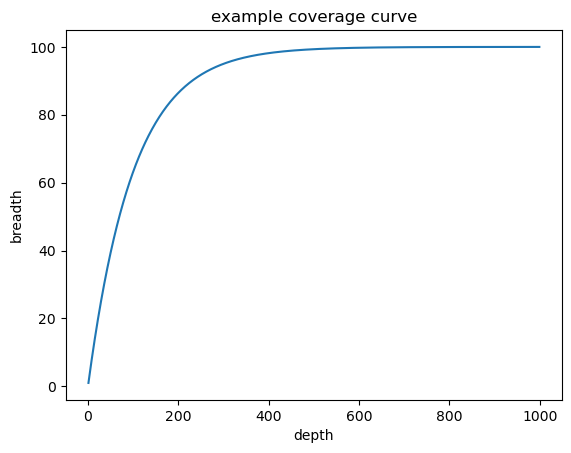

In [9]:
x = np.arange(1, 1000)
y = [ coverage_curve(xx, 100, .01) for xx in x ]
plt.plot(x, y)
plt.xlabel('depth')
plt.ylabel('breadth')
plt.title("example coverage curve")

## Build a fit function that takes weighted bp (x) and containment (y) and fits to a coverage curve

In [10]:
def do_fit(contain_df, *, fn=coverage_curve, p0=None):
    "Fit to given function, which takes two parameters, G and C. Return fit values & params."
    if p0 is None:
        p0 = (max(contain_df['weighted_bp']), .001)
    popt, pcov = scipy.optimize.curve_fit(fn, contain_df['weighted_bp'], contain_df['intersect_bp'], p0)
    G, C = popt

    y = np.asarray(contain_df['weighted_bp'])
    yfit = coverage_curve(y, G, C)

    # residual sum of squares
    ss_res = np.sum((y - yfit) ** 2)
    # total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    # r-squared
    r2 = 1 - (ss_res / ss_tot)

    return yfit, (G, C), r2

fitting for: s__Bariatricus sp004560705
fit params for s__Bariatricus sp004560705: G=1043049 C=6.186134958624553e-07; r2=-0.104


/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in exp
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/group/datalabgrp/ctbrown/2025-grist-annie/.snakemake/conda/ab4c18c32e39b7f9ba11a10bc8c18bcf_/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: overflow encountered in multiply
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


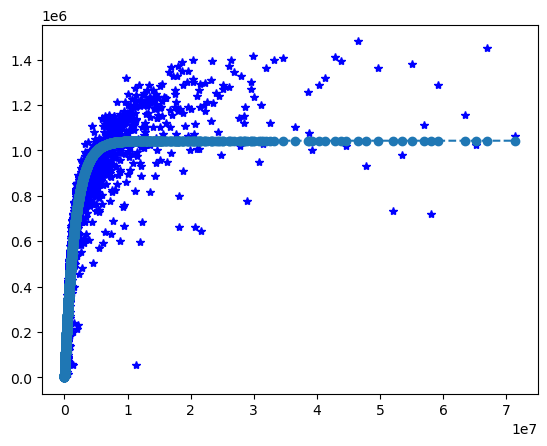

In [11]:
# test fit function!
name = NAMES[0]
print('fitting for:', NAMES[0])
species_df = manysearch_df.filter(pl.col("species") == NAMES[0]).sort(by='weighted_bp')

yfit, (G, C), r2 = do_fit(species_df)
print(f"fit params for {name}: G={G:.0f} C={C}; r2={r2:.3f}")
plt.plot(species_df['weighted_bp'], species_df['intersect_bp'], 'b*')
plt.plot(species_df['weighted_bp'], yfit, 'o--')

## Run fit function for all species, and record parameters.

In [12]:
params_d = {}
params_df = []

for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    yfit, params, r2 = do_fit(species_df)
    (GSIZE, CEXP) = params
    params_d[name] = (GSIZE, CEXP, r2)
    med = np.median(species_df['weighted_bp'] / GSIZE)
    q25 = np.percentile(species_df['weighted_bp'] / GSIZE, .25)
    num_metag = len(species_df.filter(pl.col("intersect_bp") > 20000))
#    print(f"{name:<50} {GSIZE / 1e6:.1f} Mbp    {med:.2f}        {EXP}")
    params_df.append(dict(name=name, med=med, gsize=GSIZE, exp=CEXP, num_metag=num_metag, r2=r2, q25=q25))

params_df = pl.DataFrame(params_df)

In [13]:
print("species                                     med cov       q25           gsize")
for row in params_df.sort(by='med').iter_rows(named=True):
    name, med, gsize, num_metag, r2, q25 = row["name"], row["med"], row["gsize"], row["num_metag"], row["r2"], row['q25']
    print(f"{name:<45} {med:<10.2f}  {q25:<10.4f}   {gsize/1e6:.1f}Mbp     in {num_metag}    {r2:.3f}")

species                                     med cov       q25           gsize
s__CAG-873 sp016302215                        0.01        0.0008       1.2Mbp     in 1082    0.085
s__Ruminococcoides sp902766885                0.02        0.0015       0.7Mbp     in 602    0.035
s__Blautia_A sp945872375                      0.02        0.0014       0.7Mbp     in 1084    0.231
s__SIG351 sp945918795                         0.04        0.0009       1.1Mbp     in 1665    0.348
s__Bifidobacterium thermacidophilum           0.05        0.0017       0.6Mbp     in 1487    0.008
s__CAG-465 sp000433755                        0.05        0.0049       0.2Mbp     in 643    0.369
s__Ventricola sp017937505                     0.06        0.0033       0.3Mbp     in 1074    0.283
s__CAG-269 sp014846485                        0.06        0.0044       0.2Mbp     in 905    0.075
s__Ruminococcus_C sp000433635                 0.07        0.0009       1.1Mbp     in 1825    0.041
s__UMGS1225 sp034086705           

## Update with a new fit function that we have an estimated genome size

We can now adjust 'x' by the estimated size of the (pan) genome, for each species.

Read through [the inStrain docs](https://instrain.readthedocs.io/en/latest/important_concepts.html) for some interesting context -
the coverage parameter should be ~0.88 for a full genome.

In [14]:
# try with adjusted coverage, where we divide 'x' by tbe estimated genome size
params2_d = {}
for name in NAMES:
    species_df = manysearch_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    def adj_coverage_curve(x, c, e):
        return c*(1 - np.exp(-e*x/GSIZE))

    p0 = (max(species_df['weighted_bp']), 0.9)
    _, params2, _ = do_fit(species_df, fn=adj_coverage_curve, p0=p0)
    NORM, EXP2 = params2
    print(f"{name:<50} {NORM:<10.0f} {EXP2:2f}")
    params2_d[name] = params2

s__Bariatricus sp004560705                         1043046    0.645250
s__Bifidobacterium thermacidophilum                596538     0.728500
s__Blautia_A sp945872375                           707929     0.800124
s__CAG-269 sp014846485                             226746     0.792968
s__CAG-465 sp000433755                             203208     0.744784
s__CAG-873 sp016302215                             1202798    0.762858
s__Cryptobacteroides sp900546925                   1327159    0.613436
s__Fimisoma sp002320005                            887900     0.771211
s__Gemmiger qucibialis                             601077     0.560792
s__Holdemanella porci                              277973     0.473386
s__JAFBIX01 sp021531895                            1272598    0.728966
s__JALFVM01 sp022787145                            1133362    0.542675
s__Lactobacillus amylovorus                        369692     0.284976
s__Mogibacterium_A kristiansenii                   468869     0.435221
s__Pha

In [15]:
# use the new information to estimate breadth and depth for every row, and then add into data frame.
adj_df = []

for row in manysearch_df.iter_rows(named=True):
    species = row["species"]
    metag = row["metag"]
    intersect_bp = row["intersect_bp"]
    weighted_bp = row["weighted_bp"]
    GSIZE, EXP, r2 = params_d[species]
    breadth = intersect_bp / GSIZE
    depth = weighted_bp / GSIZE
    fit_breadth = coverage_curve(weighted_bp, GSIZE, EXP) / GSIZE
    adj_df.append(dict(species=species, metag=metag, breadth=breadth, depth=depth, fit_breadth=fit_breadth))

adj_df = pl.DataFrame(adj_df)
join_df = manysearch_df.join(adj_df, on=['species', 'metag'], how='inner')
join_df

query_name,query_md5,match_name,containment,intersect_hashes,ksize,scaled,moltype,match_md5,jaccard,max_containment,average_abund,median_abund,std_abund,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,n_weighted_found,total_weighted_hashes,species,metag,sketch_size,intersect_bp,weighted_bp,breadth,depth,fit_breadth
str,str,str,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,i64,i64,f64,f64,f64
"""s__Prevotella sp002251295""","""11c2f06bb0ba002567a1bdc2a57126…","""SRR11126108""",0.102068,528,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.001608,0.102068,1.738636,1.0,1.099183,0.897025,0.736655,0.81684,0.897025,918,906559,"""s__Prevotella sp002251295""","""SRR11126108""",5.173e6,528000,918000,0.351977,0.61196,0.295499
"""s__UMGS1225 sp034086705""","""32711230ebb0936ab57ed263368289…","""SRR11126108""",0.016775,18,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000055,0.016775,1.222222,1.0,0.41574,0.823115,0.627176,0.725146,0.823115,22,906559,"""s__UMGS1225 sp034086705""","""SRR11126108""",1.073e6,18000,22000,0.01953,0.02387,0.019701
"""s__Mogibacterium_A kristiansen…","""a6063c0962c975db514497f271511e…","""SRR11126108""",0.101576,303,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000928,0.101576,2.894389,2.0,1.912803,0.896818,0.717428,0.807123,0.896818,877,906559,"""s__Mogibacterium_A kristiansen…","""SRR11126108""",2.983e6,303000,877000,0.646232,1.870446,0.55693
"""s__JAFBIX01 sp021531895""","""2902fdae1da9e7a10d826eac534864…","""SRR11126108""",0.073482,207,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000634,0.073482,1.294686,1.0,0.719044,0.883098,0.704529,0.793813,0.883098,268,906559,"""s__JAFBIX01 sp021531895""","""SRR11126108""",2.817e6,207000,268000,0.162659,0.210593,0.142311
"""s__Phascolarctobacterium_A suc…","""b8c6bbf9560cfc087687eb69f00b1c…","""SRR11126108""",0.171033,235,21,1000,"""DNA""","""dda840d6acbdbdaad918e936a03947…",0.000724,0.171033,3.370213,2.0,2.797257,0.919348,0.708798,0.814073,0.919348,792,906559,"""s__Phascolarctobacterium_A suc…","""SRR11126108""",1.374e6,235000,792000,0.777306,2.619687,0.753144
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s__Roseburia inulinivorans""","""f2654d4c2e0a7a74479c509794d10f…","""ERR8314759""",0.037142,261,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000095,0.037142,3.56705,1.0,10.879359,0.854867,0.643489,0.749178,0.854867,931,9259617,"""s__Roseburia inulinivorans""","""ERR8314759""",7.027e6,261000,931000,0.33512,1.195389,0.471915
"""s__CAG-269 sp014846485""","""078c4569f257f75356832c47c16808…","""ERR8314759""",0.009174,4,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000001,0.009174,1.5,1.5,0.5,0.799797,0.527391,0.663594,0.799797,6,9259617,"""s__CAG-269 sp014846485""","""ERR8314759""",436000.0,4000,6000,0.017641,0.026461,0.020764
"""s__Phascolarctobacterium_A suc…","""8c3d1fa61d73093ded0c14d4577909…","""ERR8314759""",0.010504,45,21,1000,"""DNA""","""33d0f71a1bb5d8498cce56b97b5b72…",0.000016,0.010504,1.711111,1.0,1.360102,0.804969,0.591817,0.698393,0.804969,77,9259617,"""s__Phascolarctobacterium_A suc…","""ERR8314759""",4.284e6,45000,77000,0.708088,1.211618,0.552804


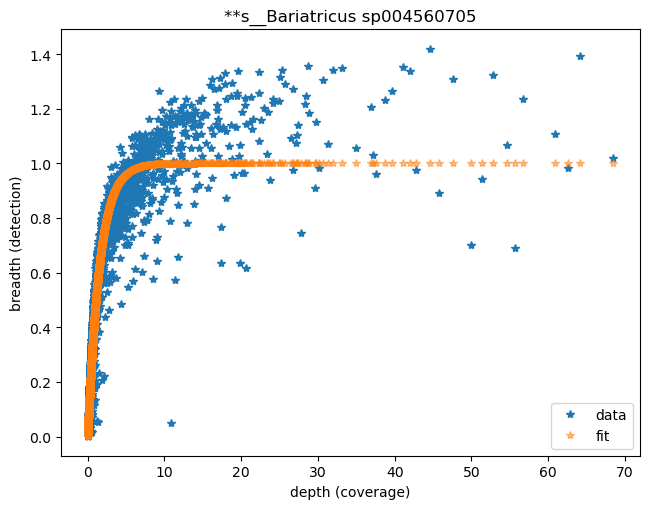

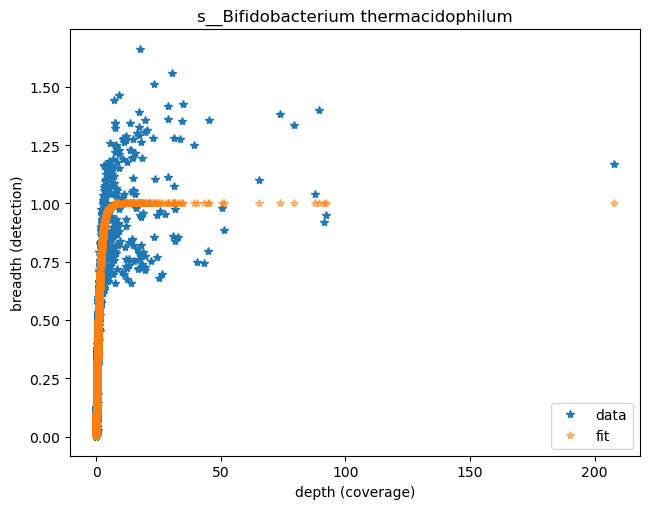

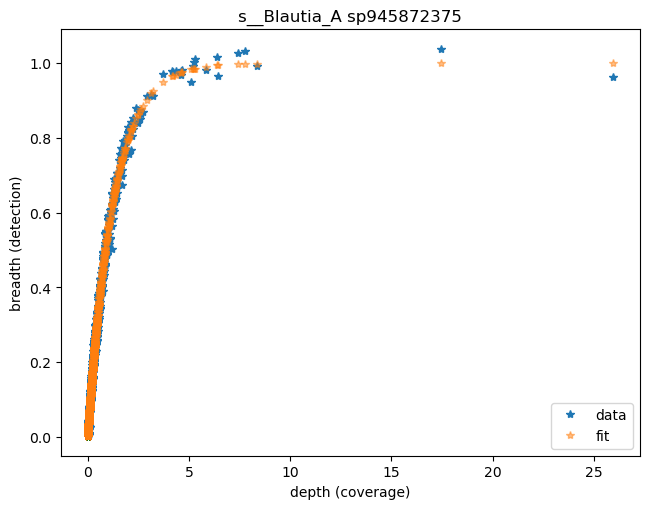

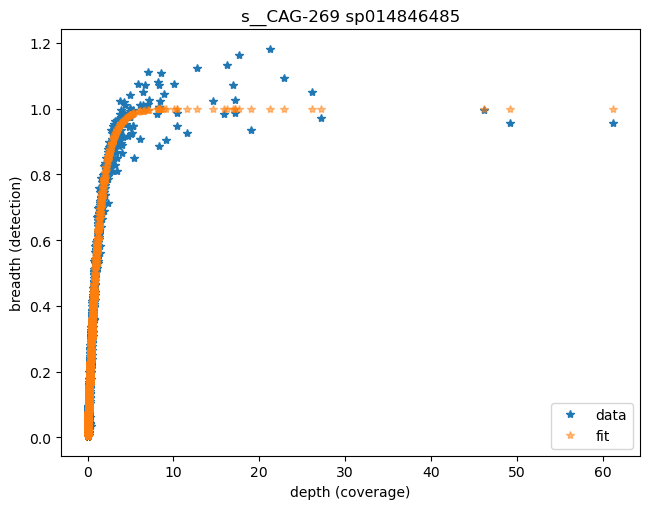

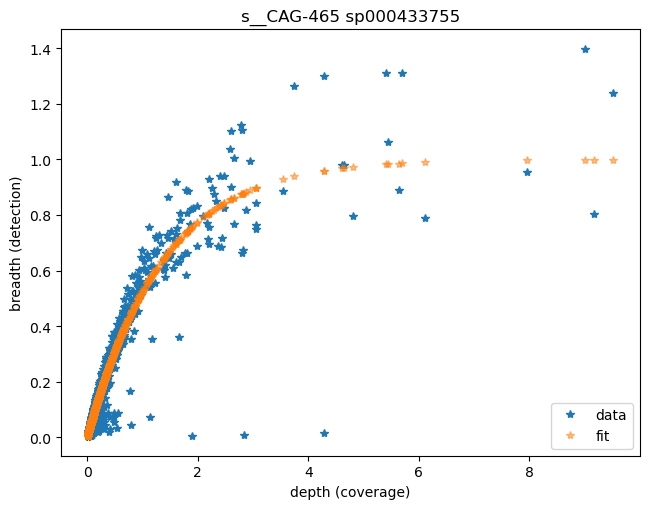

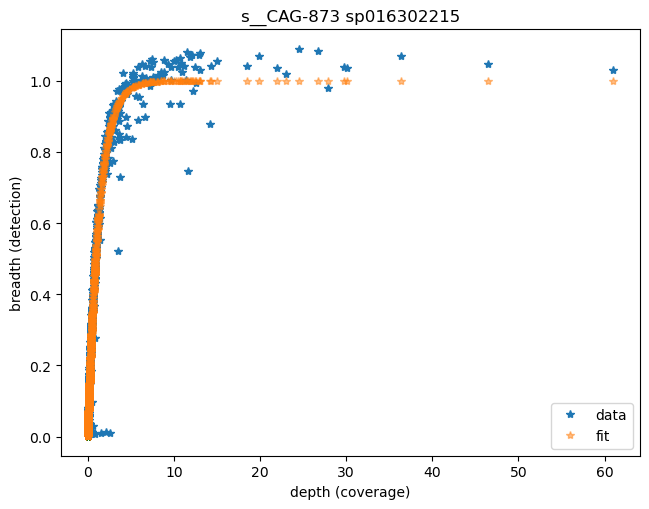

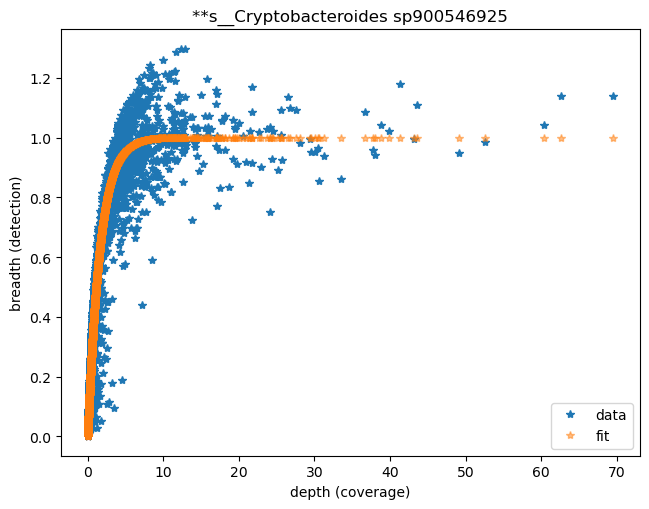

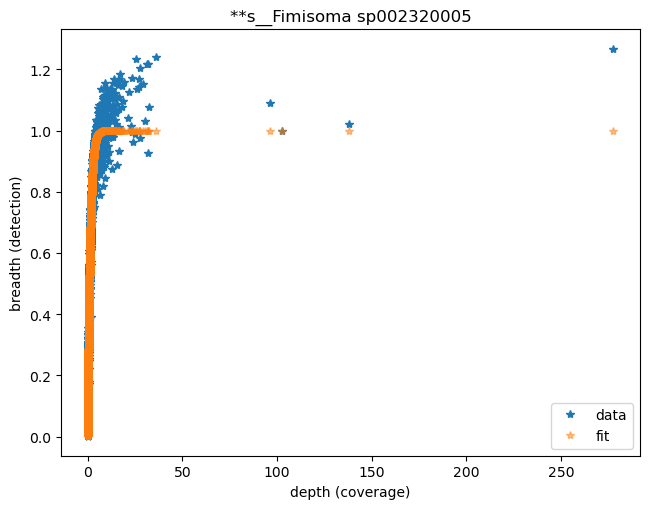

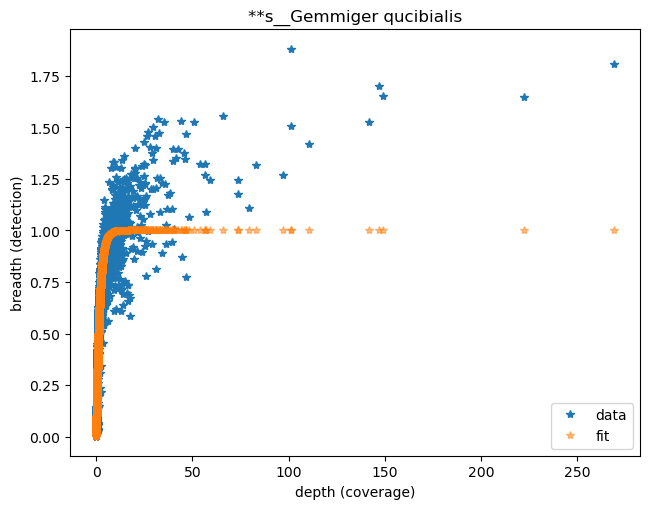

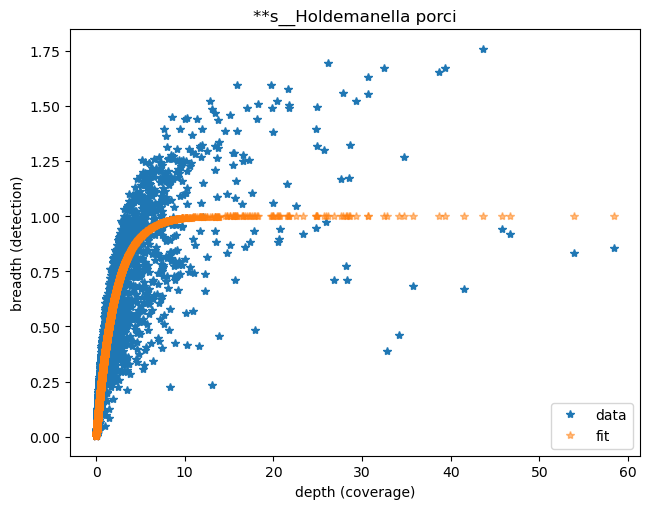

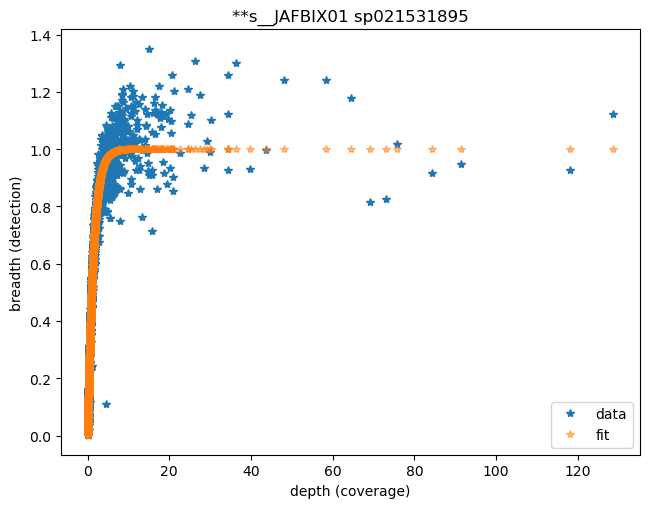

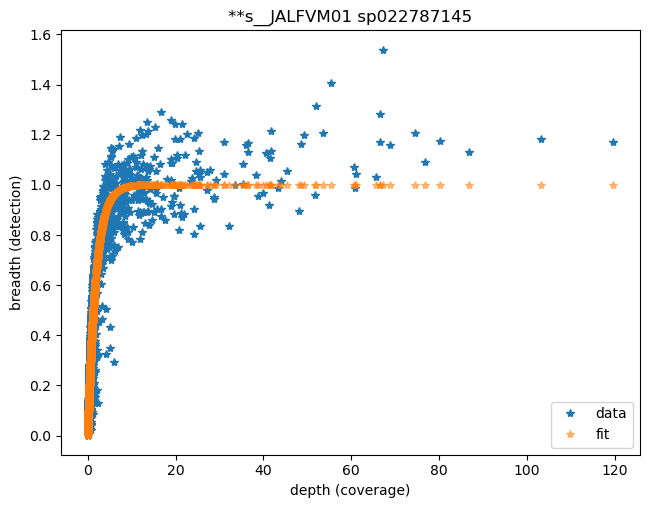

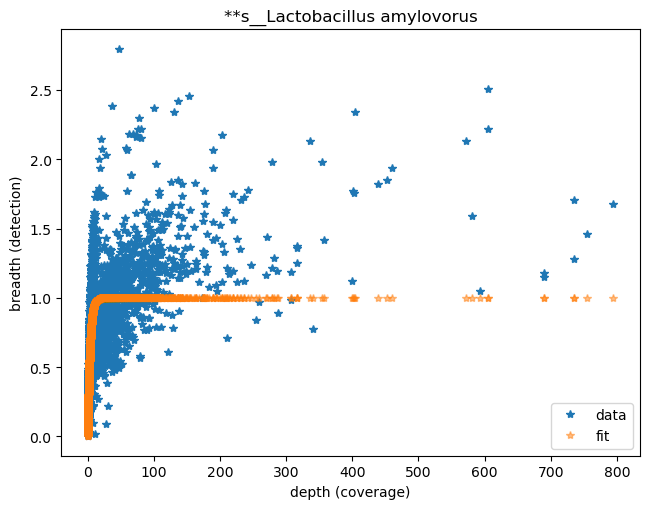

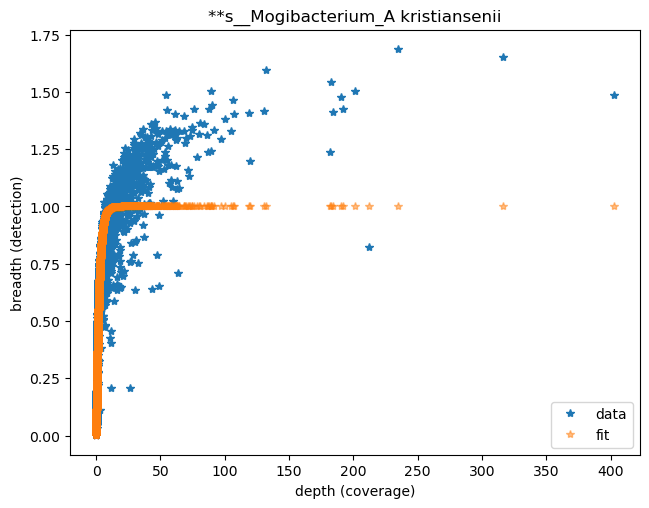

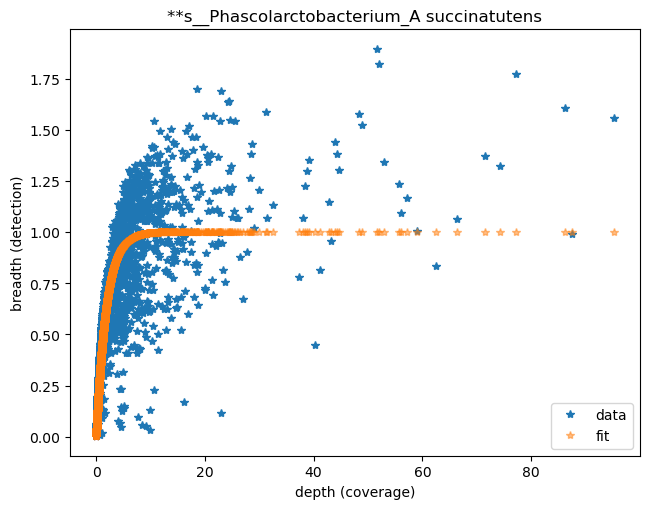

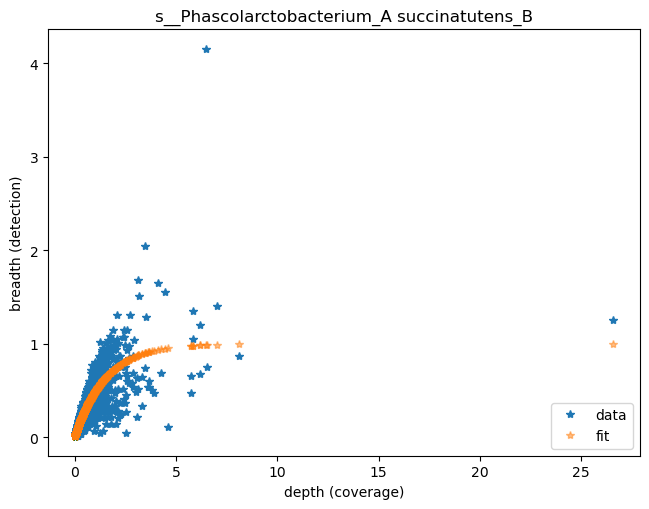

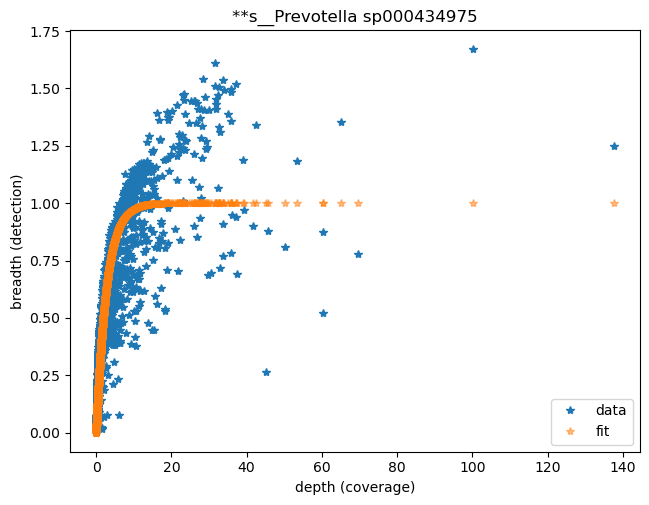

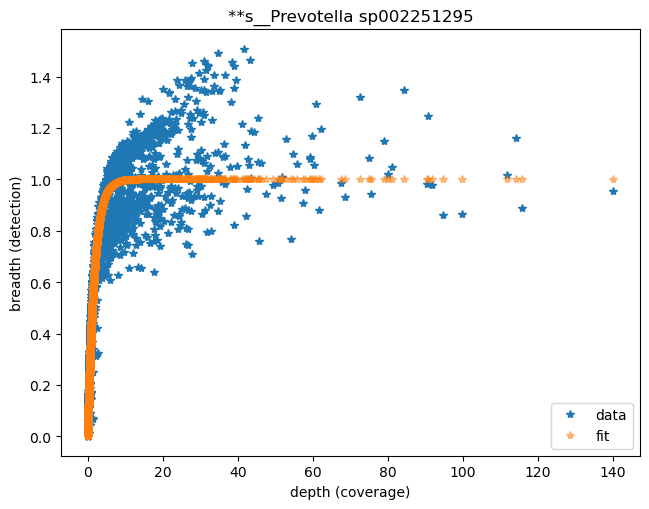

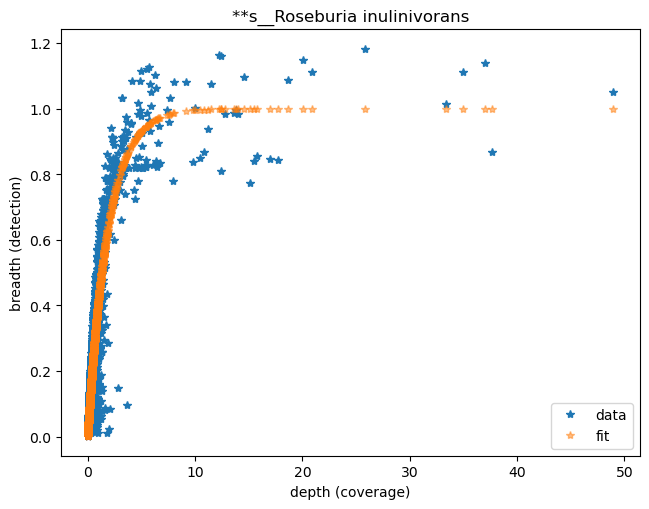

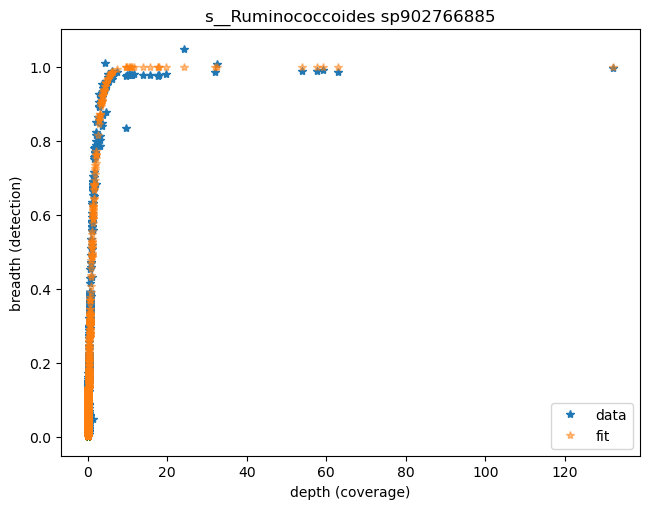

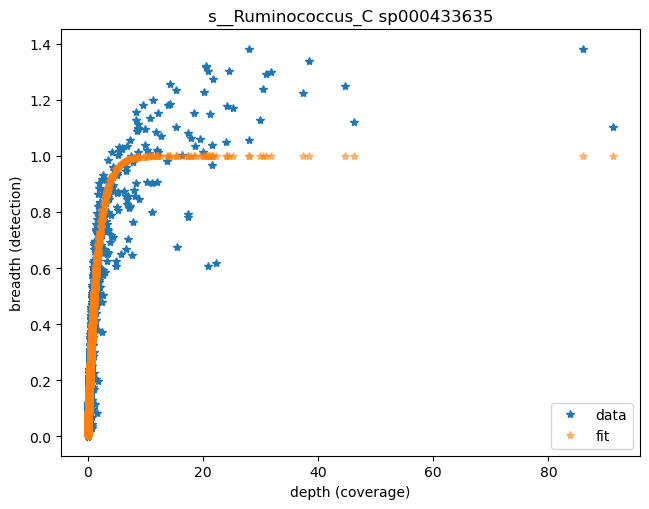

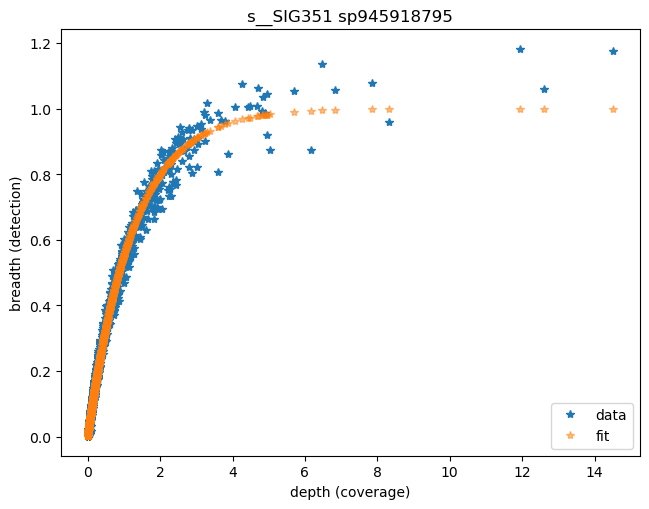

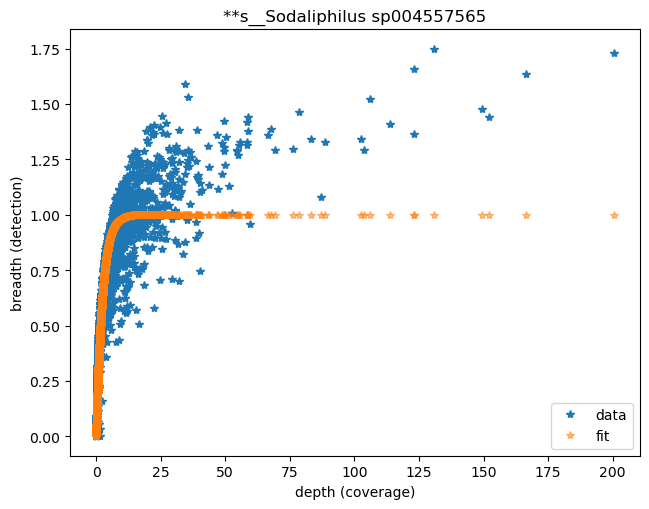

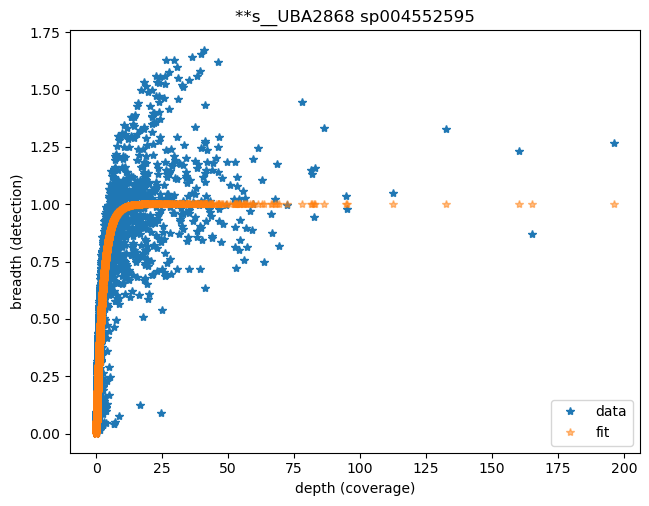

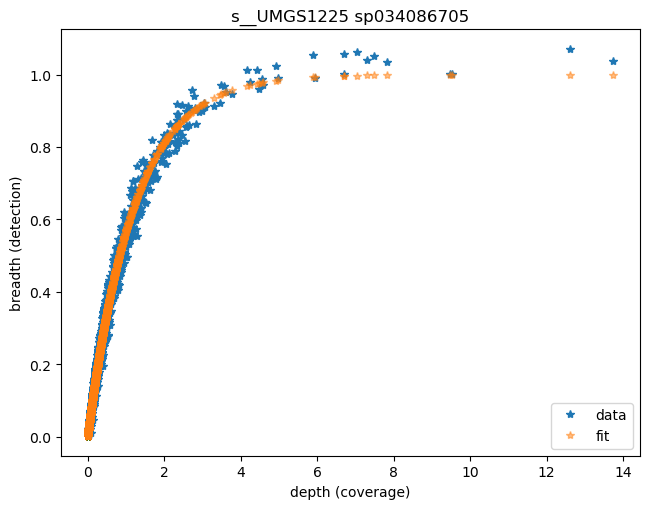

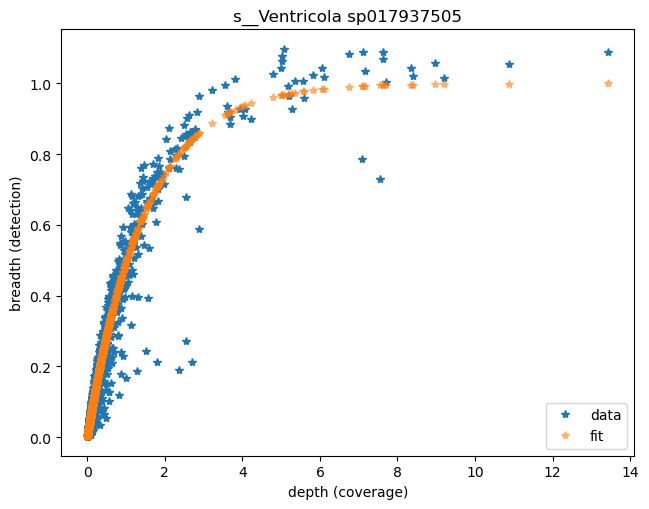

In [16]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)

    plt.plot(species_df['depth'], species_df['breadth'], '*', label='data')
    plt.plot(species_df['depth'], species_df['fit_breadth'], '*', alpha=0.5, label='fit')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('depth (coverage)')
    plt.ylabel('breadth (detection)')
    plt.legend(loc='lower right')

    #plt.xlim(0, 3)
    #plt.ylim(0, 1.5)
    plt.show()


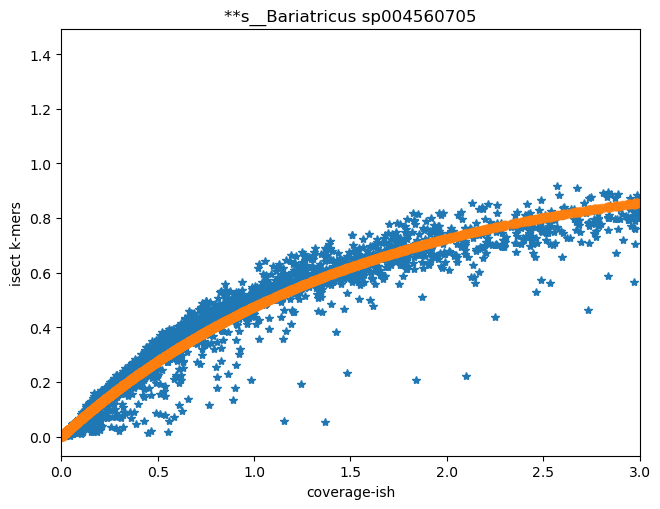

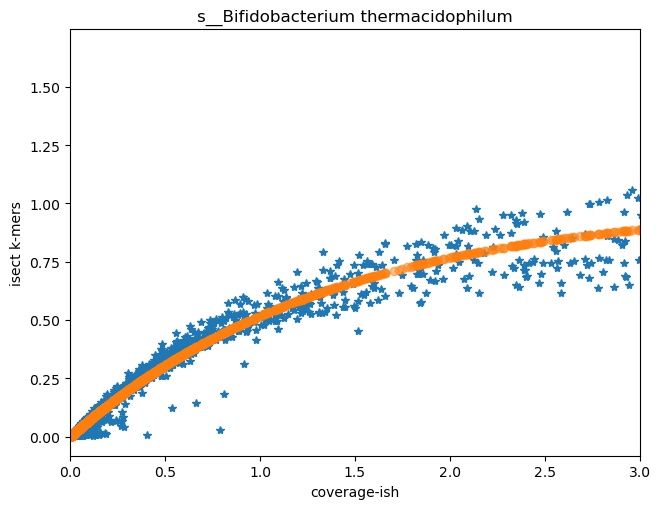

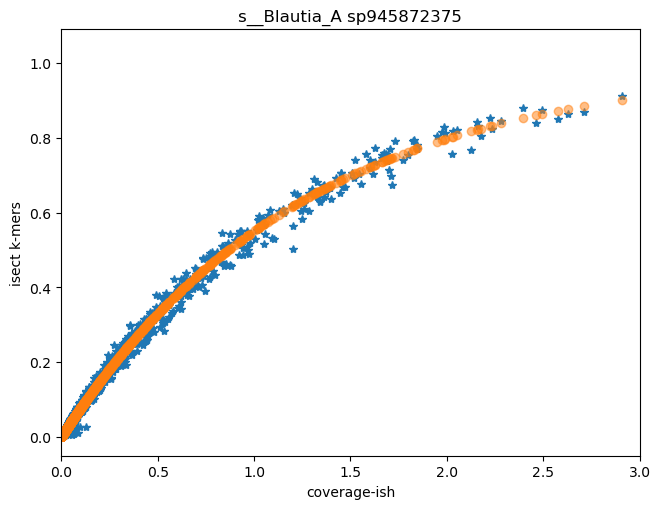

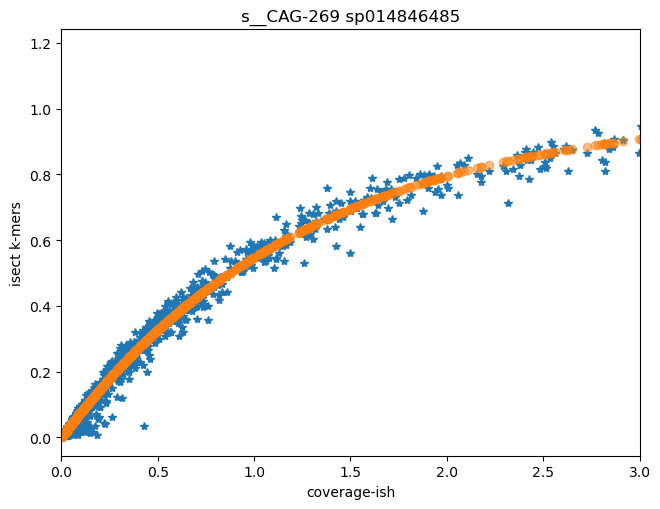

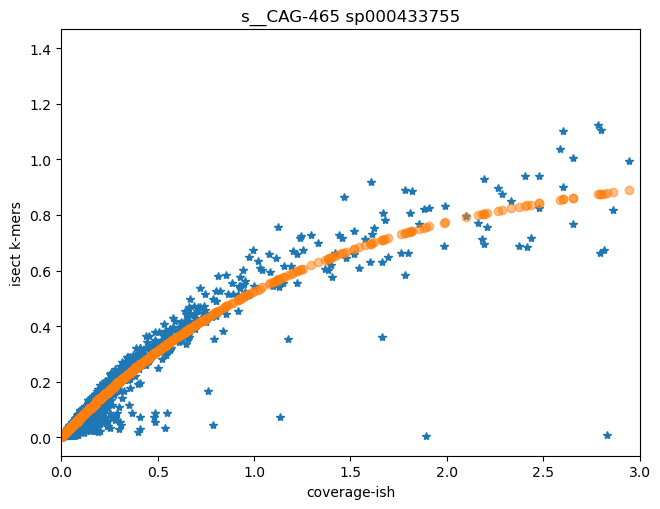

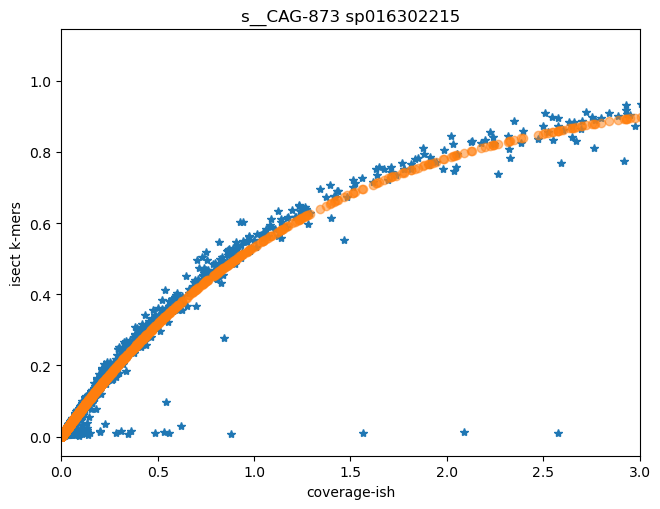

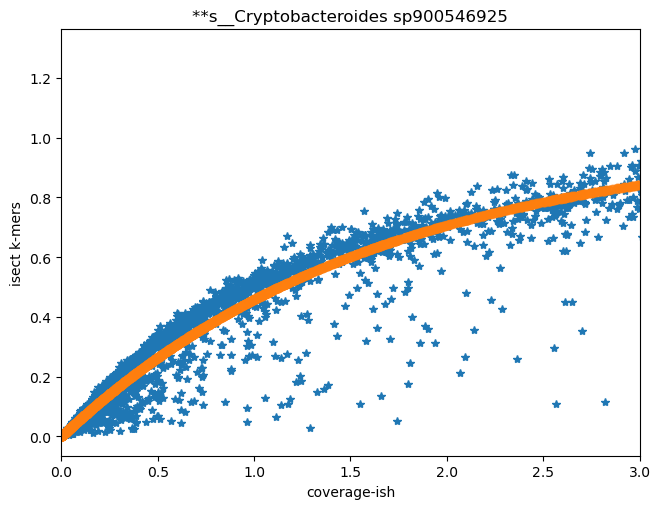

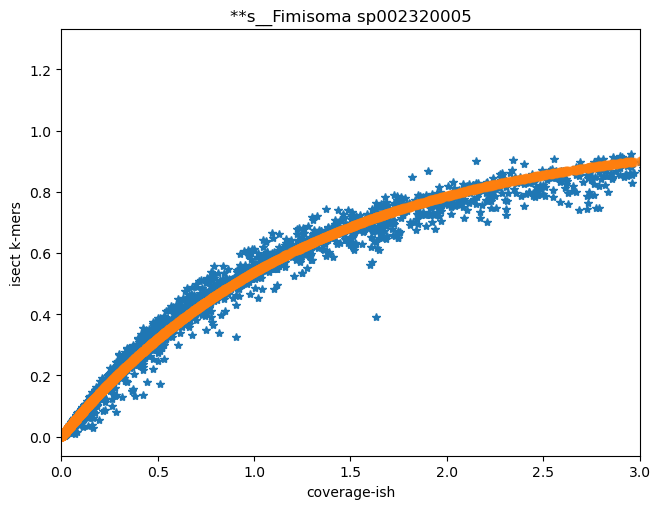

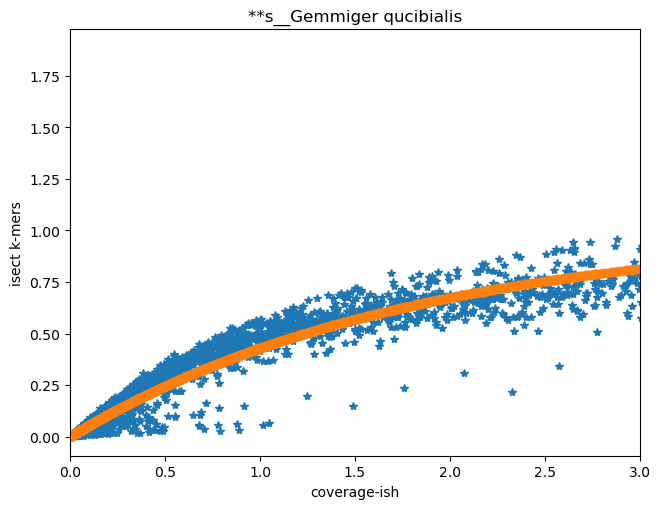

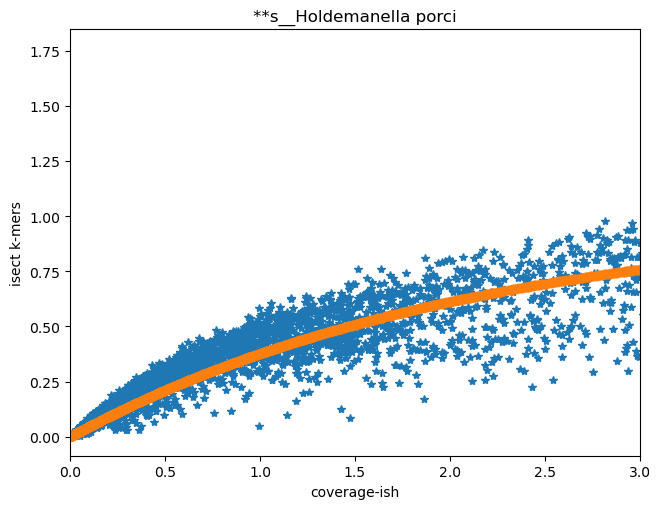

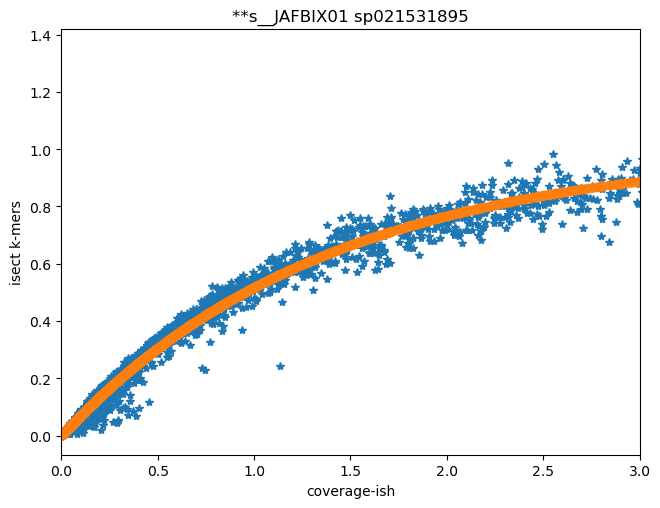

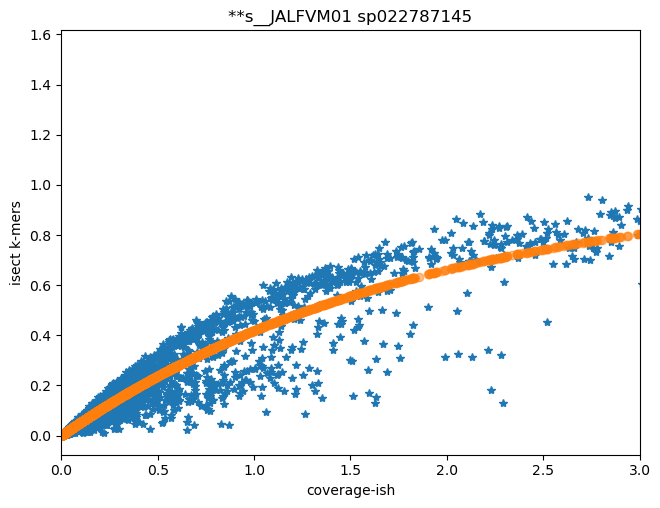

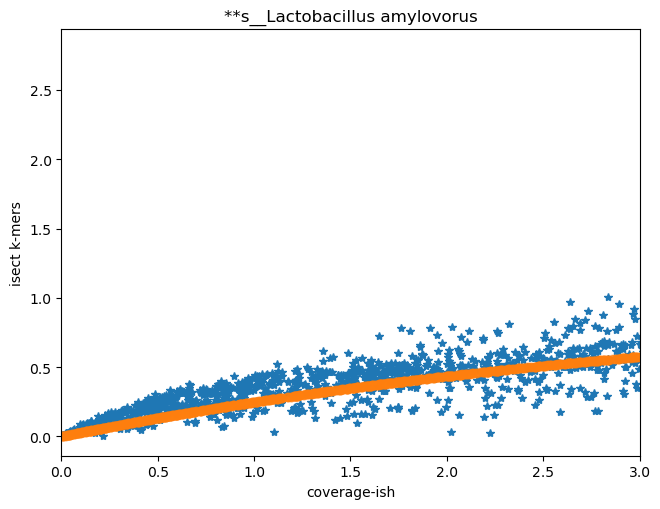

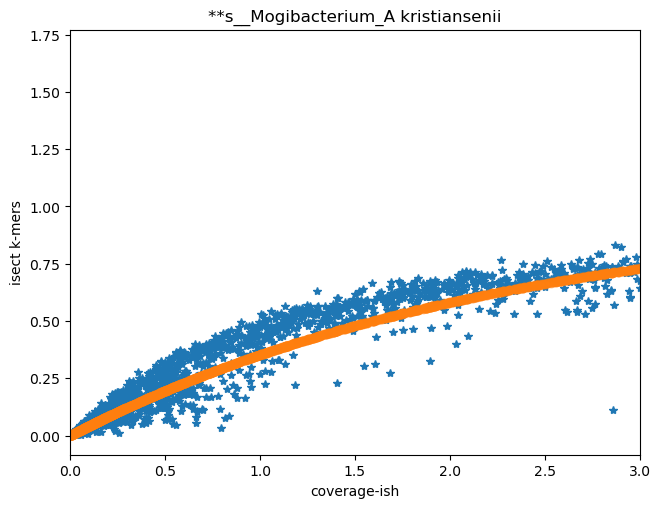

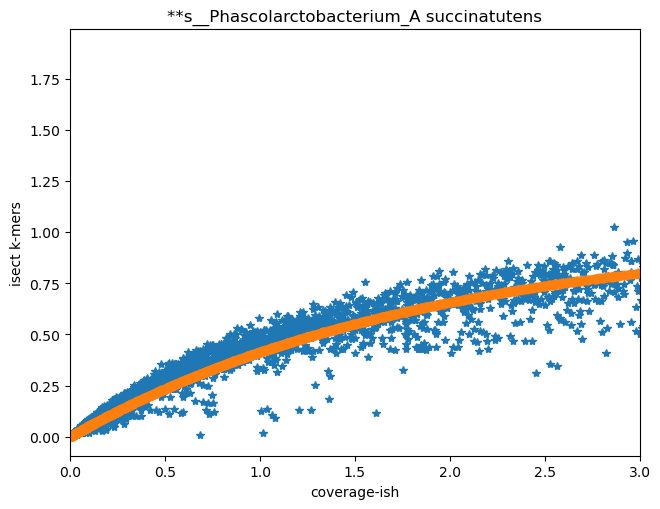

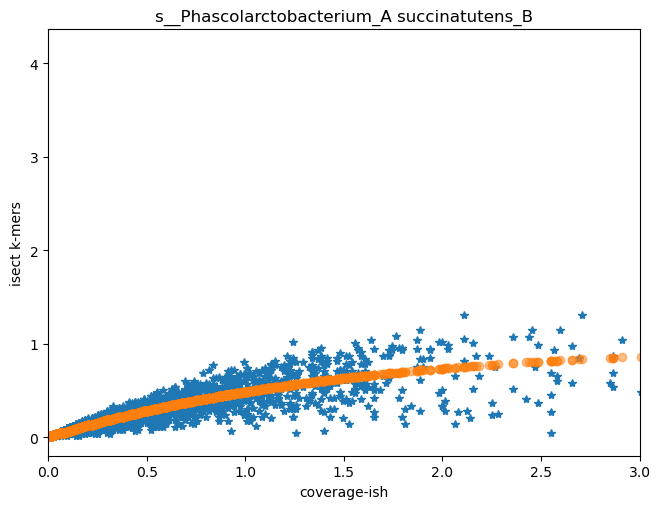

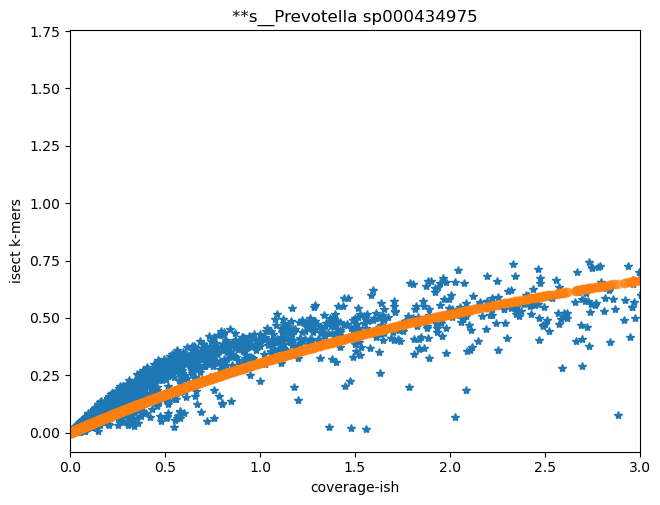

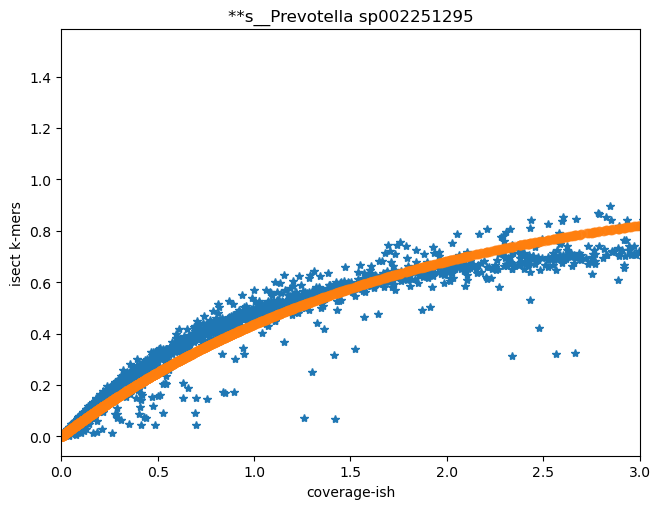

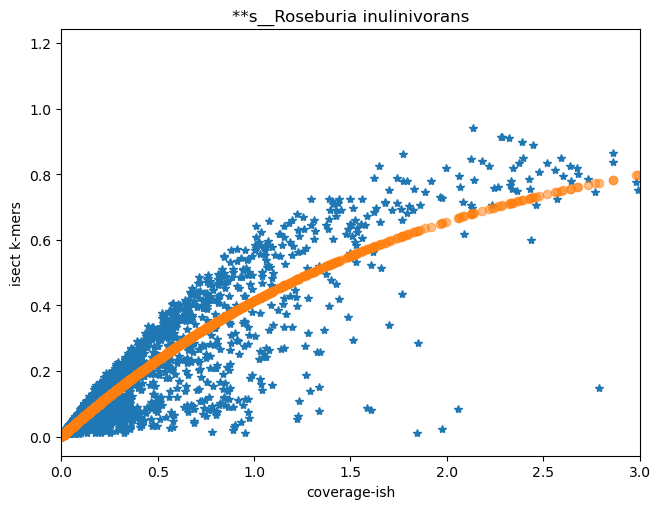

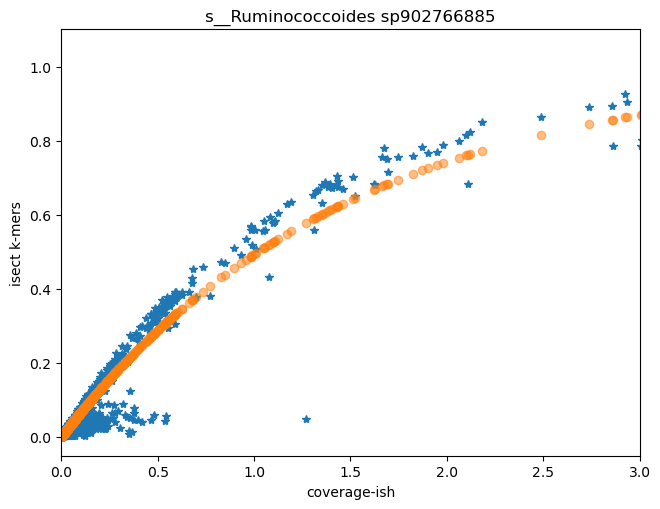

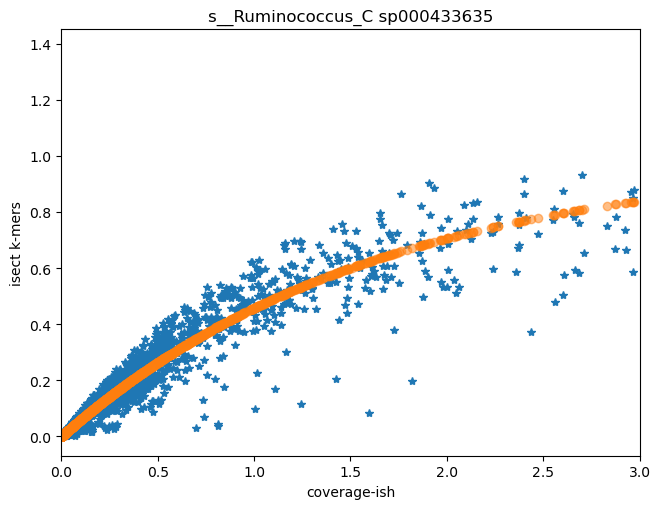

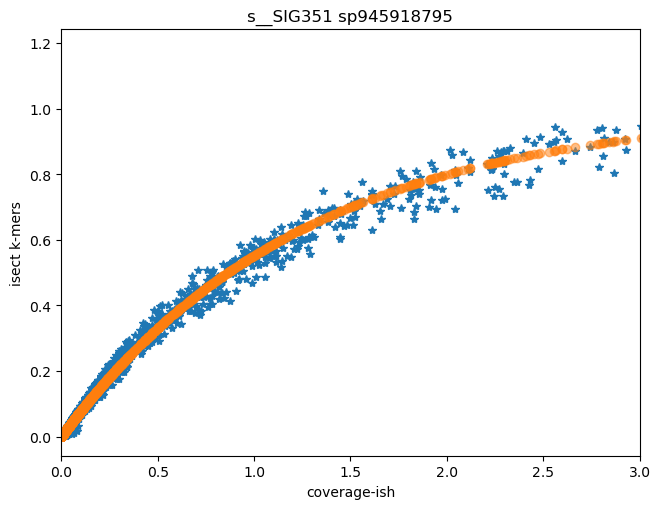

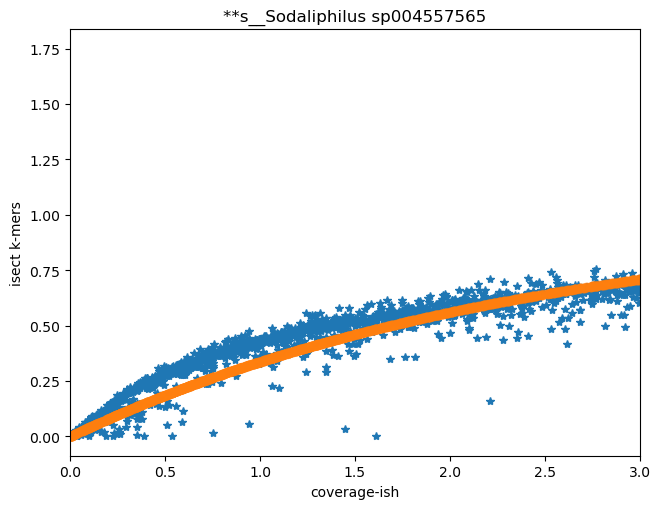

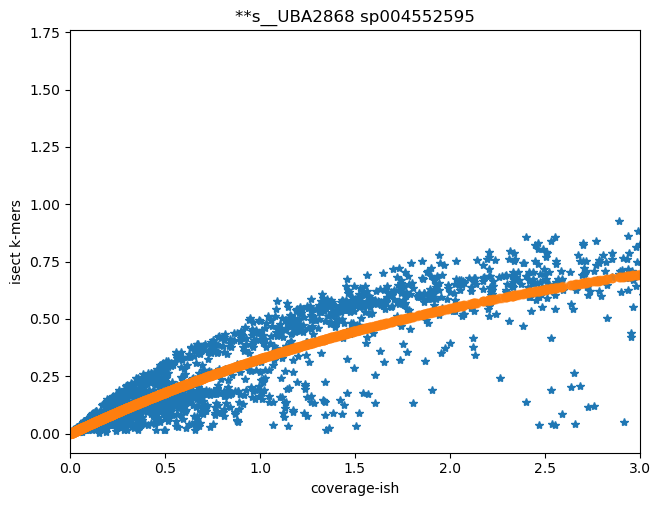

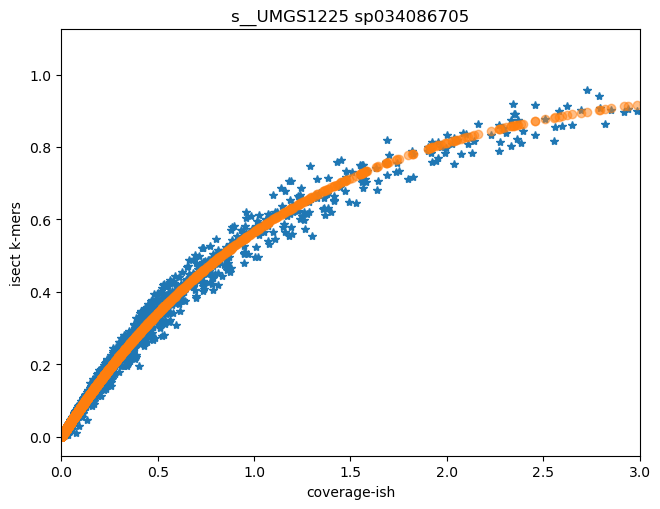

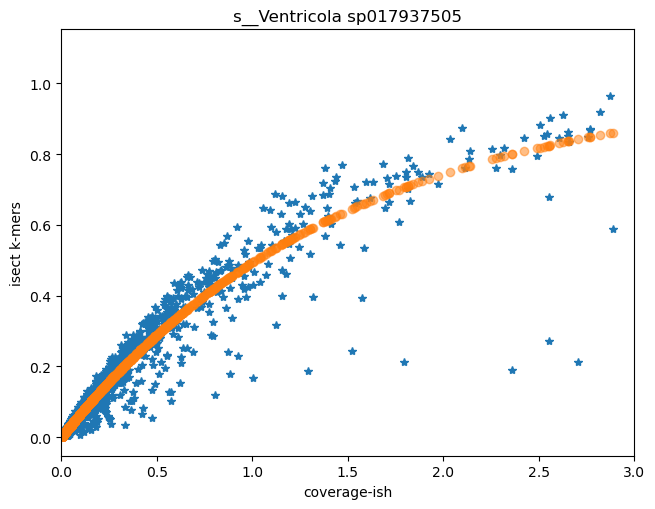

In [17]:
for name in NAMES:
    species_df = join_df.filter(pl.col("species") == name)
    GSIZE, EXP, r2 = params_d[name]

    plt.plot(species_df['weighted_bp'] / GSIZE, species_df['intersect_bp'] / GSIZE, '*')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlabel('coverage-ish')
    plt.ylabel('isect k-mers')

    yfit = coverage_curve(species_df['weighted_bp'], GSIZE, EXP)
    plt.plot(species_df['weighted_bp'] / GSIZE, yfit / GSIZE, 'o', alpha=0.5)
    plt.xlim(0, 3)
    plt.show()


## Can we correlate with metagenome sequencing depth?

Answer: no, not really. Presumably biology is involved (that is, actual abundance of microbes is different in different metagenomes!)

In [18]:
metadata_df = pl.scan_parquet('/group/ctbrowngrp5/sra-metagenomes/20241128-metadata.parquet')
metadata_df = metadata_df.select(["acc", "organism", "assay_type", "mbases"])\
    .filter(pl.col("acc") != "NP")\
    .filter(pl.col("assay_type") == "WGS")

metadata_df = metadata_df.collect()
metadata_df

acc,organism,assay_type,mbases
str,str,str,i64
"""SRR28523869""","""human metagenome""","""WGS""",258
"""SRR19901137""","""Streptococcus suis""","""WGS""",40
"""SRR24962475""","""Escherichia coli""","""WGS""",88
"""SRR29161330""","""biofilm metagenome""","""WGS""",3
"""SRR26668739""","""bovine gut metagenome""","""WGS""",129
…,…,…,…
"""ERR4174288""","""human gut metagenome""","""WGS""",1017
"""ERR3160109""","""human gut metagenome""","""WGS""",133
"""ERR2709457""","""human gut metagenome""","""WGS""",964


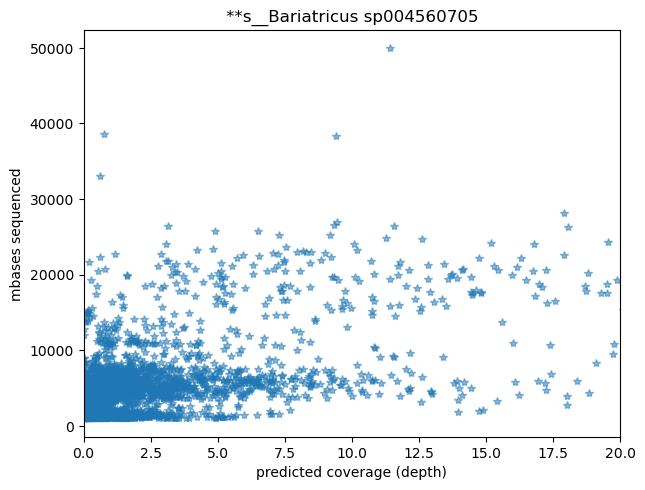

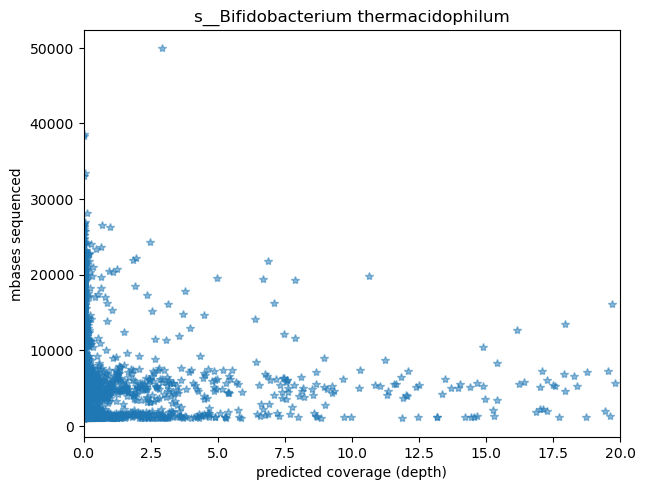

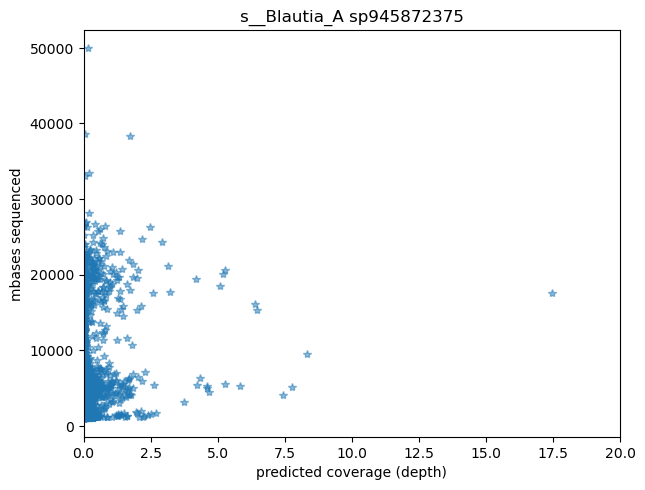

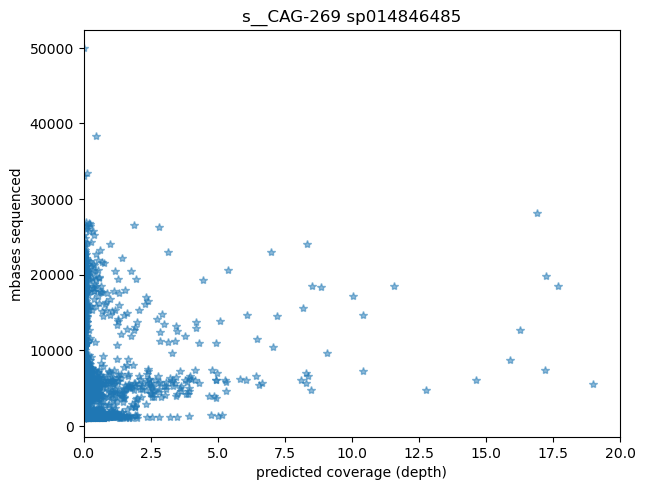

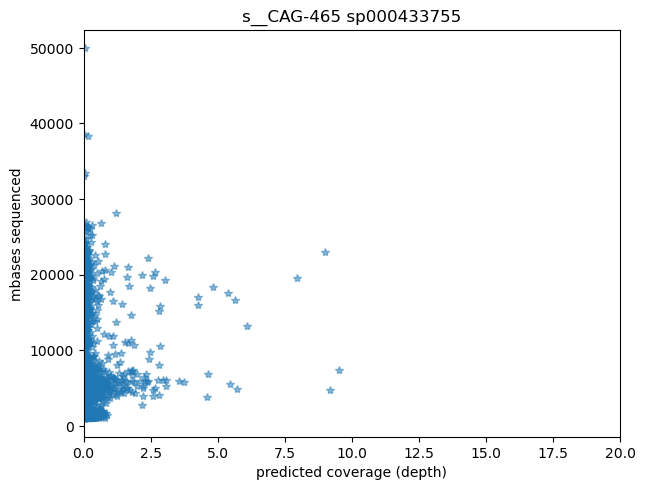

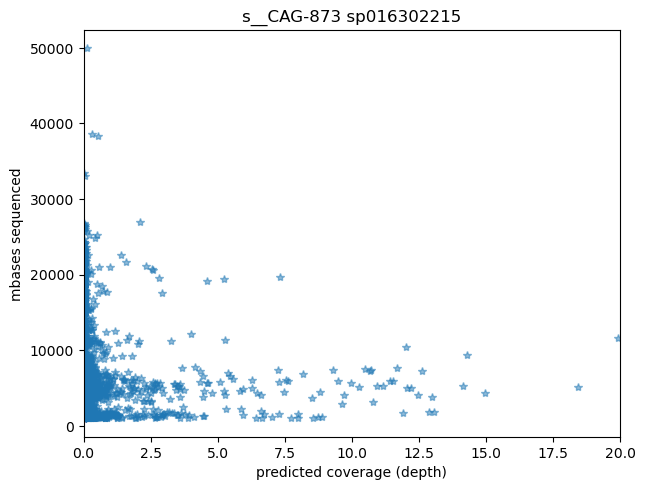

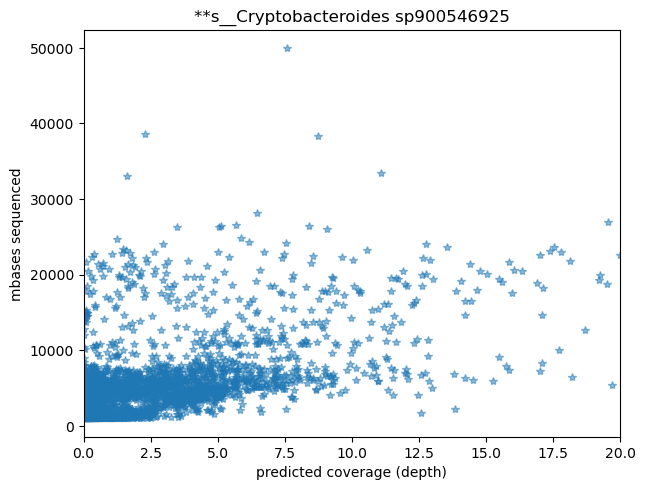

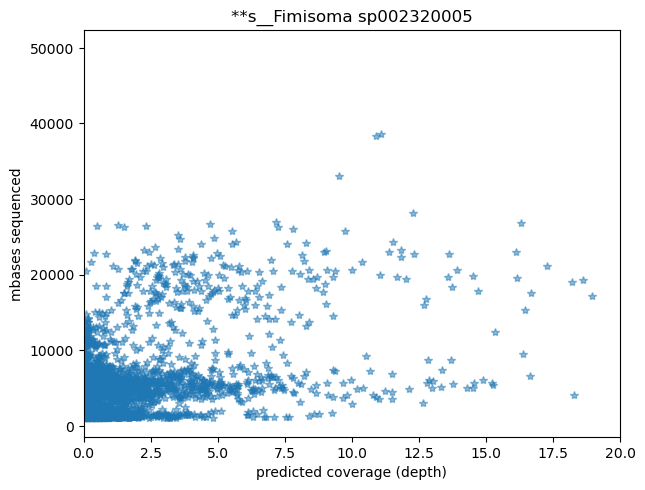

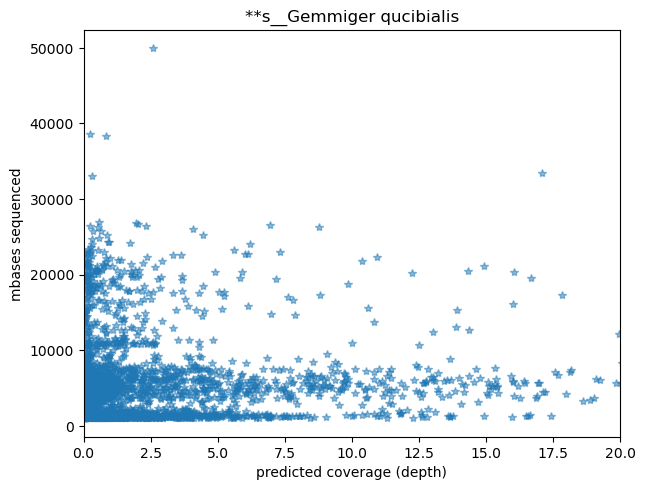

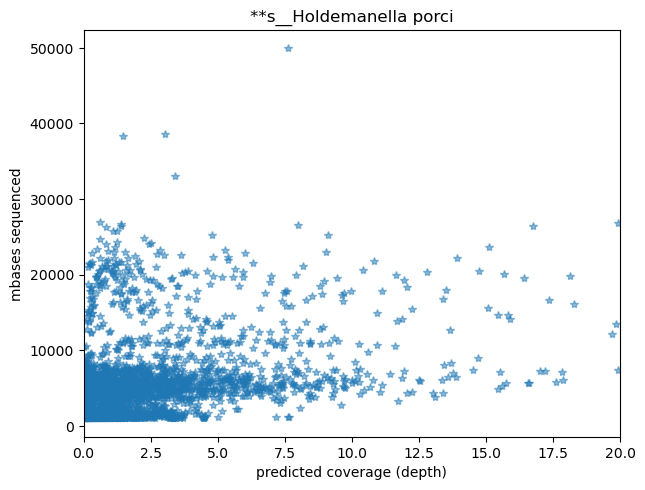

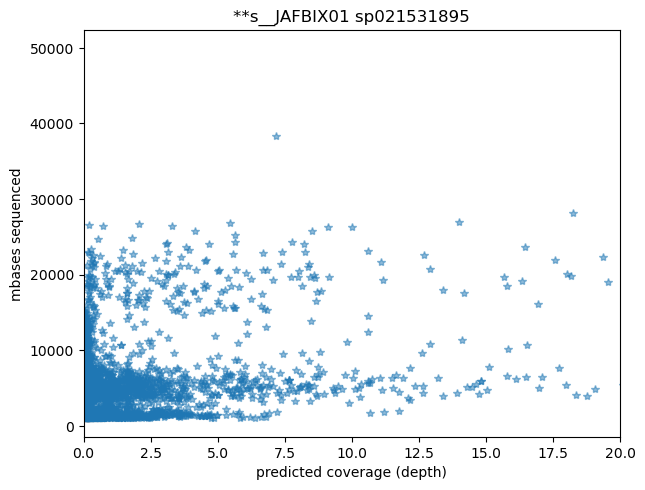

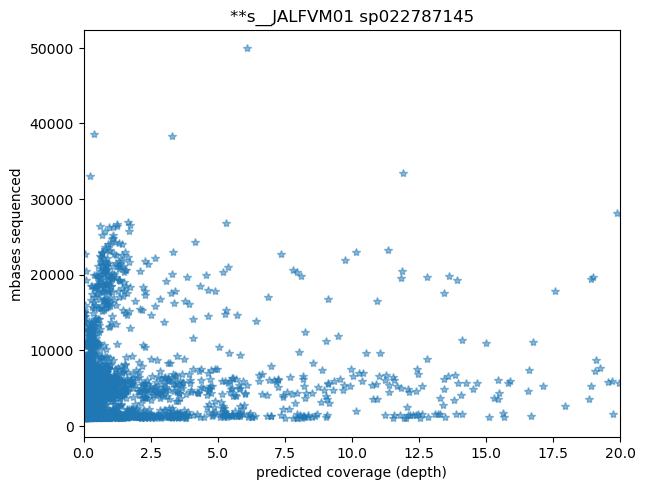

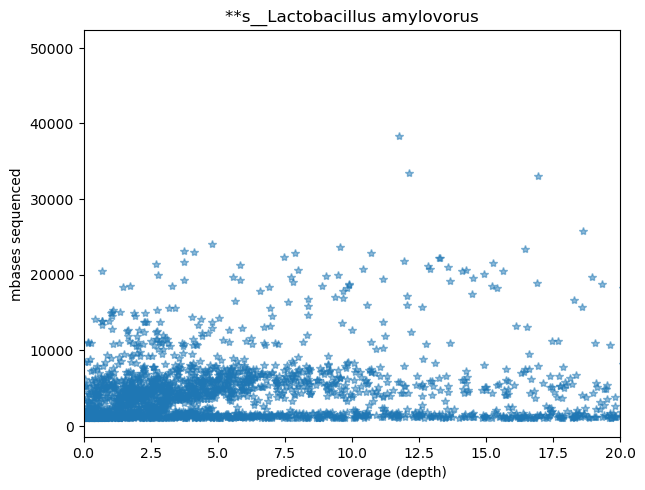

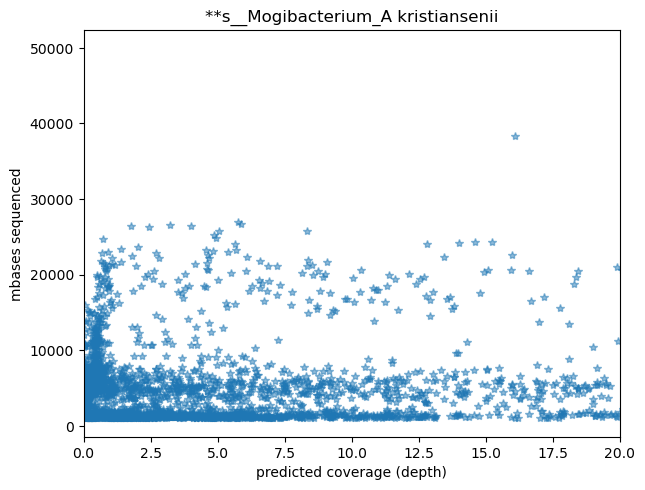

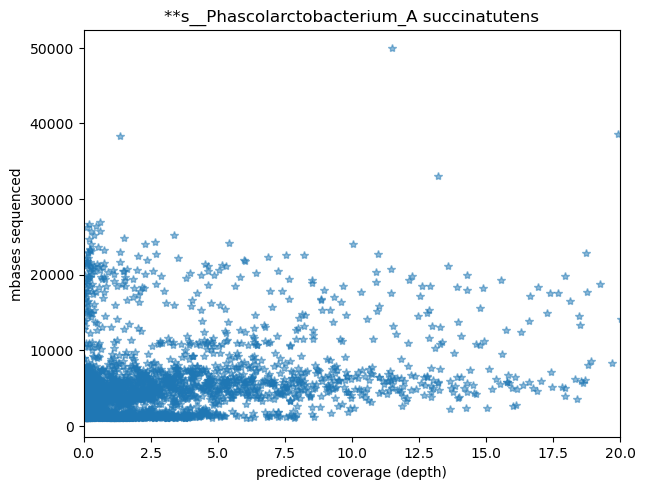

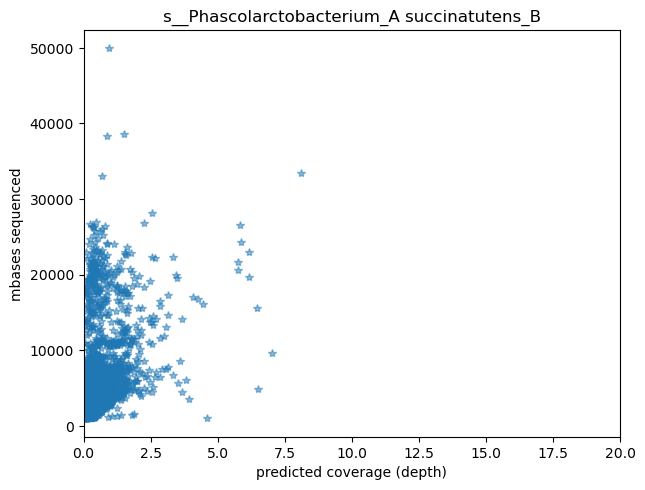

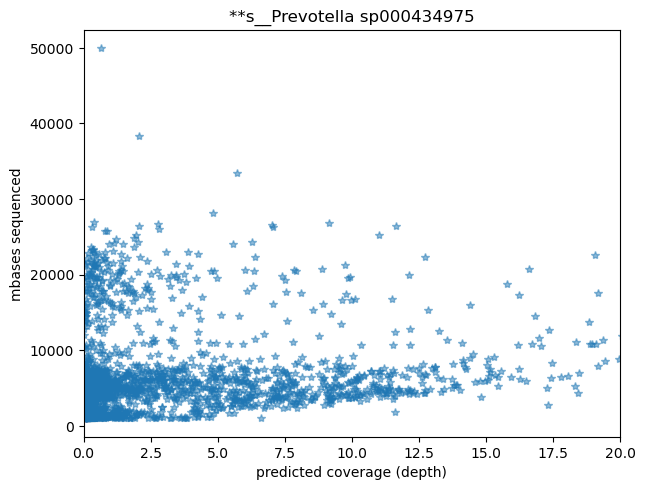

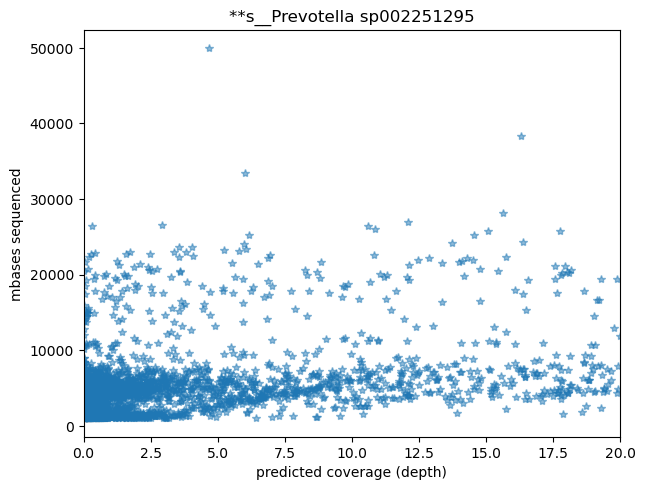

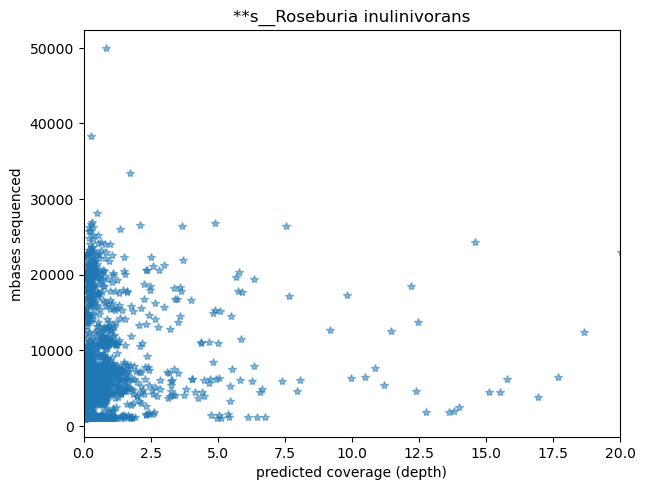

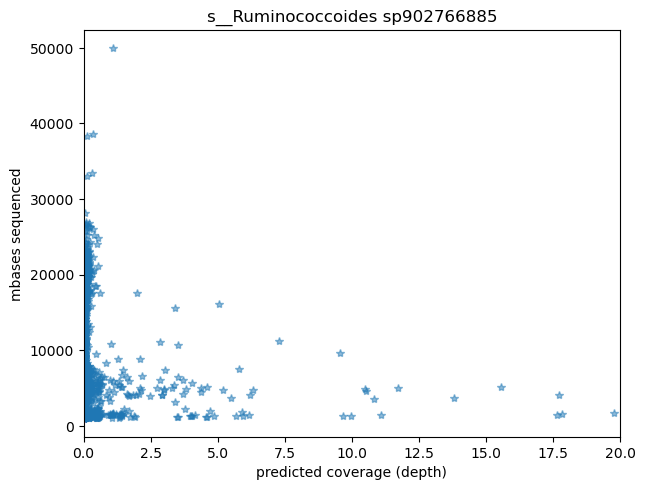

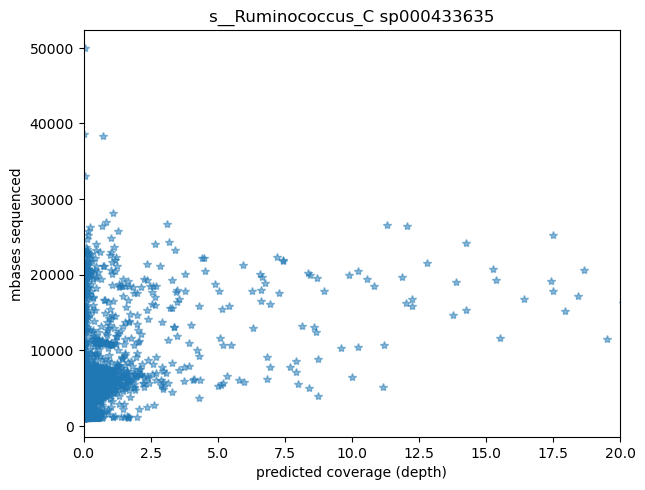

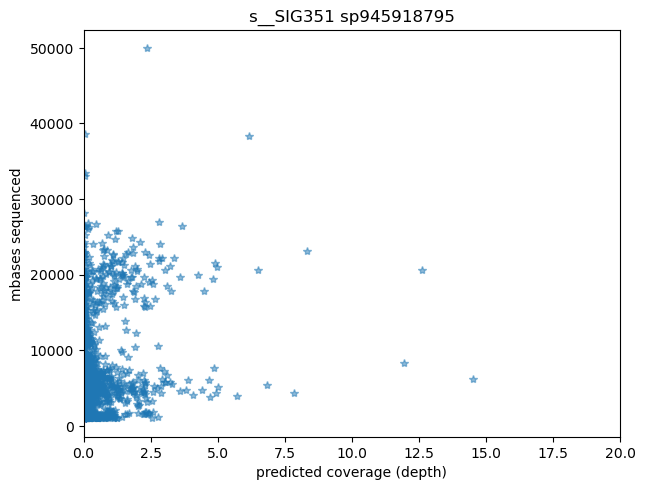

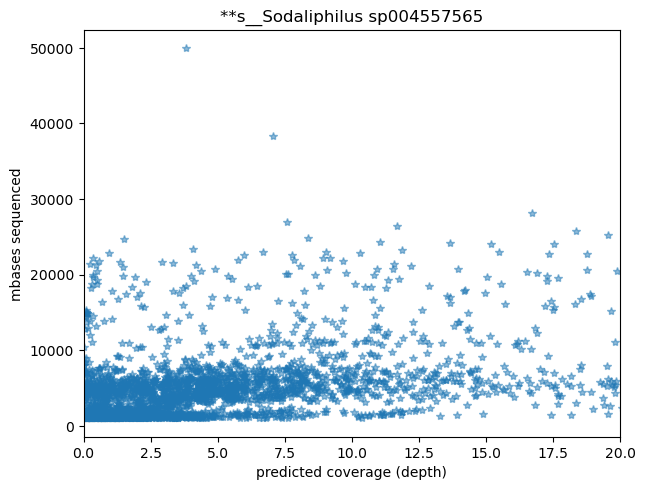

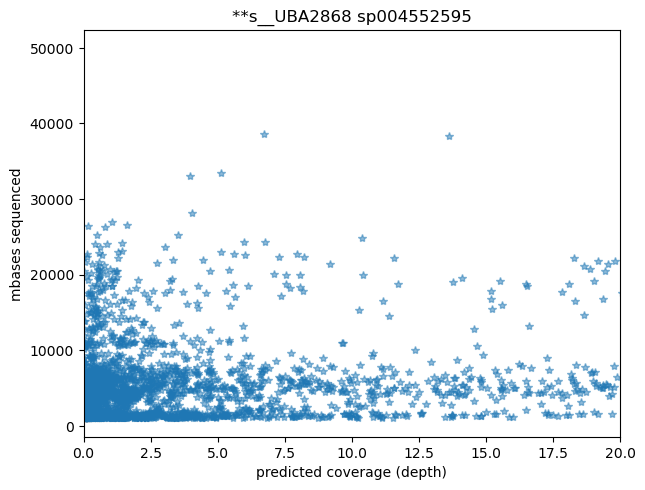

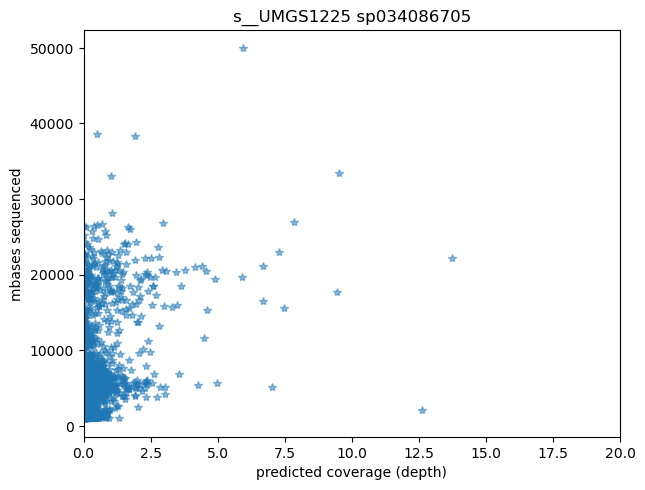

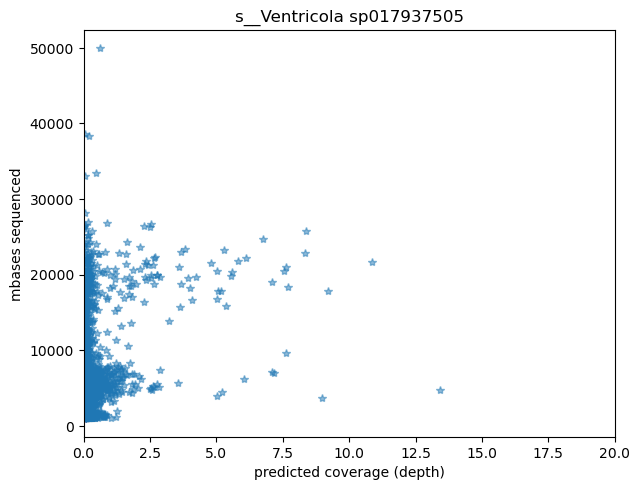

In [19]:
for name in sorted(NAMES):
    species_df = join_df.filter(pl.col("species") == name)
    foo_df = species_df.join(metadata_df, left_on='metag', right_on='acc', how='inner')
    plt.plot(foo_df['depth'], foo_df['mbases'], '*', alpha=0.5)
    plt.xlabel('predicted coverage (depth)')
    plt.ylabel('mbases sequenced')
    plt.tight_layout()
    if name in SPECIAL:
        plt.title('**' + name)
    else:
        plt.title(name)
    plt.xlim(0, 20)
    plt.show()

## Can we correlate with mapping to genes?

Basically, yes!

Here we are evaluating our k-mer collector's curves of coverage (y axis) against mapping based coverage using the species-specific genes. If we get straight lines (and we do!) then we win!

I'm not entirely sure why the slopes vary tho. Working on it.

In [20]:
gene_df = pl.read_csv('../outputs.cds/cds3-genes/mapping-coverage.csv')
gene_df

metag,species,gene,len,hits,breadth,depth_all,depth_cov
str,str,str,i64,i64,f64,f64,f64
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""LJHBCGLM_01294""",393,0,0.0,0.0,NaN
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""PKGEEMPI_00758""",1347,595,0.441722,0.778768,1.763025
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""AKLOHKAG_01416""",603,0,0.0,0.0,NaN
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""DKAPMIEG_00121""",564,127,0.225177,0.381206,1.692913
"""ERR1135199""","""s__Mogibacterium_A kristiansen…","""IEPMJGAI_00771""",420,115,0.27381,0.27381,1.0
…,…,…,…,…,…,…,…
"""ERR8314743""","""s__Lactobacillus amylovorus""","""BBOFCOCJ_01349""",1134,959,0.845679,4.582892,5.419187
"""ERR8314743""","""s__Lactobacillus amylovorus""","""OBGMJDLM_01221""",2574,2574,1.0,12.188034,12.188034
"""SRR12795793""","""s__Bariatricus sp004560705""","""AIEIMHOC_00182""",768,333,0.433594,0.897135,2.069069


In [21]:
gene_avg_df = gene_df.group_by(["metag", "species"]).agg(
    pl.col("depth_all").mean(),
    pl.col("depth_cov").mean(),
)
gene_avg_df

metag,species,depth_all,depth_cov
str,str,f64,f64
"""SRR17241521""","""s__JALFVM01 sp022787145""",0.770026,2.0
"""SRR17241596""","""s__Cryptobacteroides sp9005469…",1.926641,4.391577
"""SRR8960379""","""s__Sodaliphilus sp004557565""",11.237081,11.469251
"""SRR8960625""","""s__Prevotella sp000434975""",0.772951,2.061789
"""ERR3211974""","""s__Phascolarctobacterium_A suc…",2.249846,3.107175
…,…,…,…
"""SRR11125751""","""s__JALFVM01 sp022787145""",0.741602,2.296
"""ERR1135459""","""s__Phascolarctobacterium_A suc…",0.610601,2.482632
"""ERR3212024""","""s__Cryptobacteroides sp9005469…",0.0,NaN


In [22]:
join2_df = join_df.with_columns(
    pl.col("query_name").alias("species"),
    pl.col("match_name").alias("metag"),
    pl.col("depth").alias("depth_est"),
).select(["species", "metag", "depth_est"])
join2_df

species,metag,depth_est
str,str,f64
"""s__Prevotella sp002251295""","""SRR11126108""",0.61196
"""s__UMGS1225 sp034086705""","""SRR11126108""",0.02387
"""s__Mogibacterium_A kristiansen…","""SRR11126108""",1.870446
"""s__JAFBIX01 sp021531895""","""SRR11126108""",0.210593
"""s__Phascolarctobacterium_A suc…","""SRR11126108""",2.619687
…,…,…
"""s__Roseburia inulinivorans""","""ERR8314759""",1.195389
"""s__CAG-269 sp014846485""","""ERR8314759""",0.026461
"""s__Phascolarctobacterium_A suc…","""ERR8314759""",1.211618


In [23]:
combo_df = join2_df.join(gene_avg_df, on=["species", "metag"], how="inner")
combo_df

species,metag,depth_est,depth_all,depth_cov
str,str,f64,f64,f64
"""s__Prevotella sp002251295""","""SRR14812372""",6.170925,11.334461,12.056659
"""s__Mogibacterium_A kristiansen…","""SRR14812372""",5.462044,3.442203,4.248076
"""s__Phascolarctobacterium_A suc…","""SRR14812372""",4.620836,10.416681,10.729679
"""s__Sodaliphilus sp004557565""","""SRR14812372""",5.174016,21.728208,22.114788
"""s__JALFVM01 sp022787145""","""SRR14812372""",0.211759,0.692506,2.0
…,…,…,…,…
"""s__JALFVM01 sp022787145""","""SRR17241596""",0.585868,1.651163,1.930514
"""s__Bariatricus sp004560705""","""SRR17241596""",5.27492,9.858619,10.785189
"""s__Cryptobacteroides sp9005469…","""SRR17241596""",1.429369,1.926641,4.391577


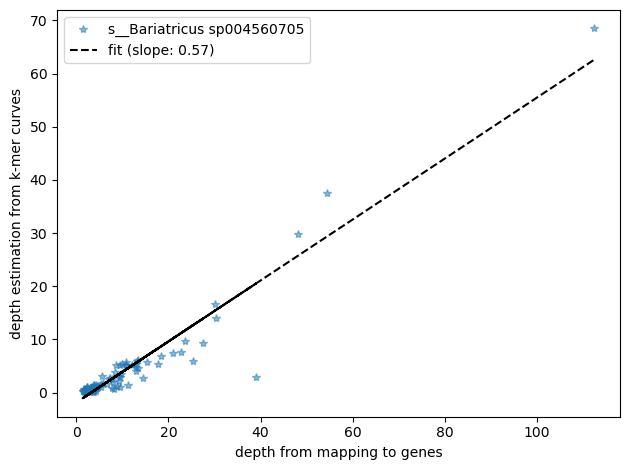

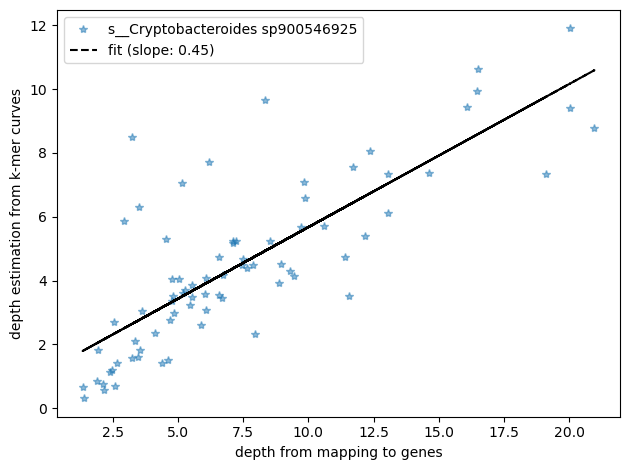

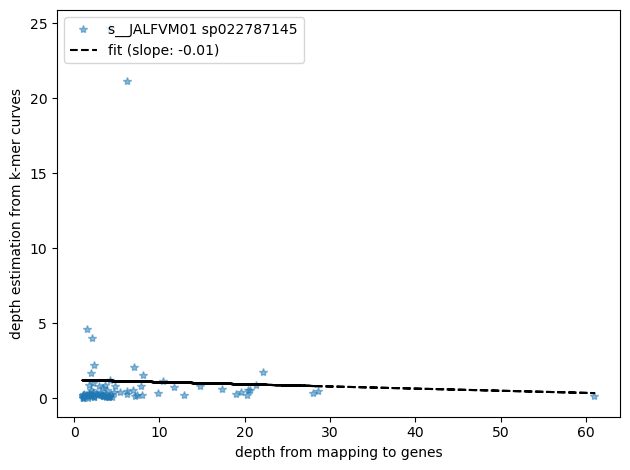

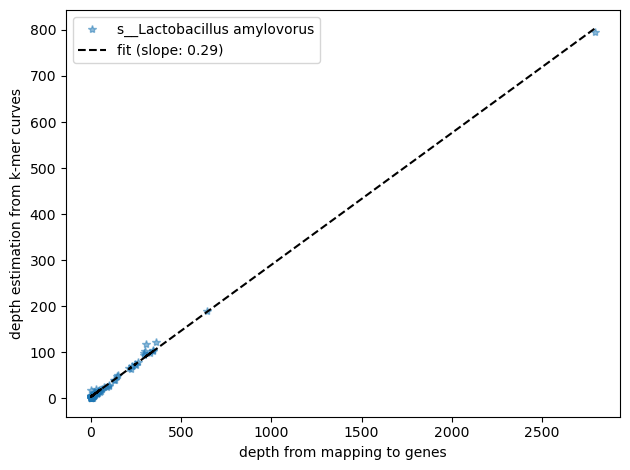

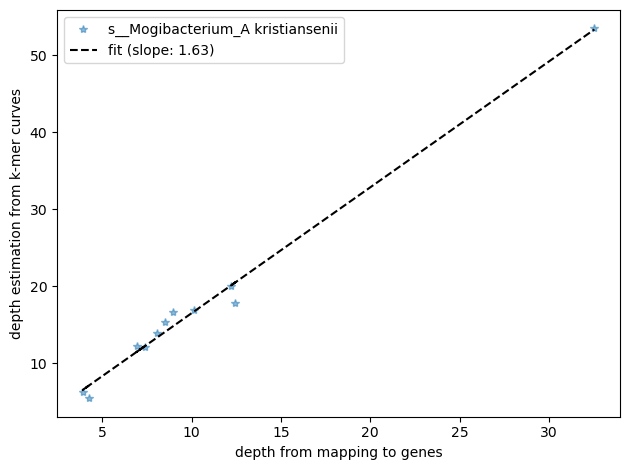

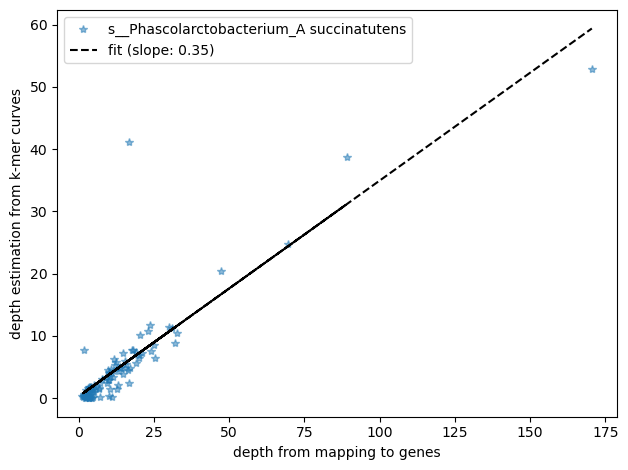

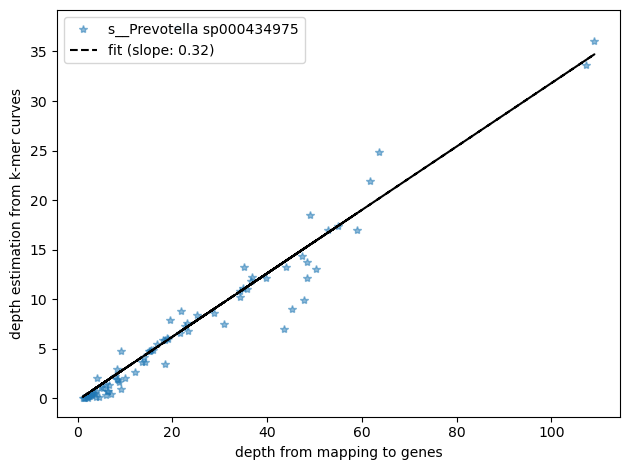

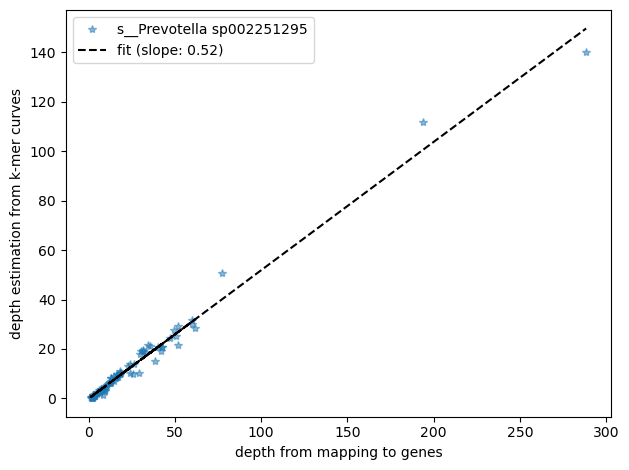

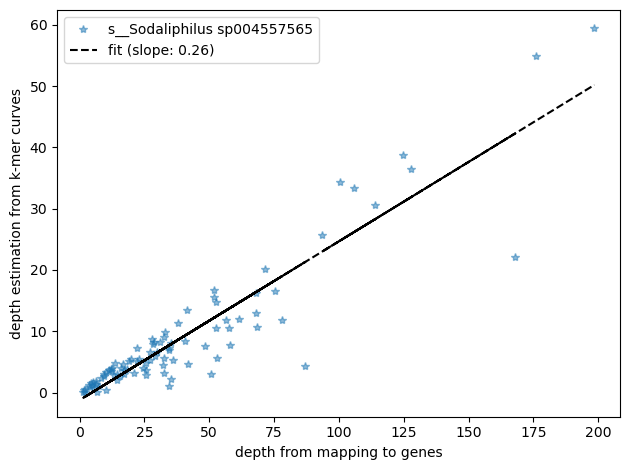

In [25]:
for species in sorted(combo_df['species'].unique()):
    xx_df = combo_df.filter(pl.col("species") == species).drop_nans().sort(by='depth_est')
    q95 = xx_df['depth_est'].to_list()[int(0.9 * len(xx_df))]
    xx2_df = xx_df.filter(
        pl.col("depth_est") < q95
    )
    x = xx_df['depth_cov']
    y = xx_df['depth_est']
    plt.plot(x, y, '*', alpha=0.5, label=species)

    coef = np.polyfit(x, y, 1)
    poly1d_fn = np.poly1d(coef) 
    plt.plot(x, poly1d_fn(x), '--k', label=f'fit (slope: {coef[0]:.2f})')
    
    #plt.xlim(0, 600)
    #plt.ylim(0, 200)
    plt.xlabel('depth from mapping to genes')
    plt.ylabel('depth estimation from k-mer curves')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()